<a href="https://colab.research.google.com/github/dennymarcels/AreTheseTwoPeopleRelated/blob/master/nmt/%5BNMT%5D_Gerar_corpus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Sobre
Objetivo(s) desse Notebook:

Gerar novas versões (a partir dos dados do Firebase) ou atualizar as versões existentes dos corpora utilizados para treinar/validar o treinamento da NMT.

A geração geralmente compreende a inclusão de dados novos (por exemplo, criação de vídeos), e a atualização se refere a mudanças nos dados já existentes (por exemplo, união de sinais).

Mais informações sobre os corpora utilizados: https://www.notion.so/handtalk/Gera-o-de-Senten-as-Paralelas-2d551274839641f2858d3f7d44a3298c

<font color='yellow'>É recomendado gerar uma cópia deste notebook para cada `CORPUS_GROUP` (`TRAIN` ou `VALIDATION`) desejado.</font>

# ⚙️ Instalações e Importações

In [1]:
# Autenticação Google
from google.colab import auth, output
auth.authenticate_user()

Download de projeto(s)

In [2]:
# Download Pytools
!gcloud source repos clone github_hand-talk_pytools --project='ht-community'

$ git clone https://github.com/Hand-Talk/pytools
Cloning into '/content/github_hand-talk_pytools'...
remote: Total 1412 (delta 763), reused 1412 (delta 763)
Receiving objects: 100% (1412/1412), 807.44 KiB | 2.27 MiB/s, done.
Resolving deltas: 100% (763/763), done.
Project [ht-community] repository [github_hand-talk_pytools] was cloned to [/content/github_hand-talk_pytools].


Instalações

In [3]:
# Instalando Pytools
!pip install ./github_hand-talk_pytools

Processing ./github_hand-talk_pytools
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.9/119.9 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 38.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 62.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 74.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.9/585.9 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 61.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.3/98.3 kB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 64.4 MB/s eta 0

## Importações

In [4]:
import tempfile
import os
import re

from pprint import pprint

import cereja as cj
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cereja import Progress
from datetime import datetime
from handtalk.community import Community
from handtalk.gcloud.firebase import Firebase, Storage
from collections import defaultdict, OrderedDict
from pathlib import Path

🍒 Using Cereja v.1.9.9


# 🛠️ Funções

In [5]:
def get_corpus_filenames(workspace: str, corpus: str, version: str = '', view_blobs: bool = False) -> list:
    """
    Recupera os nome de todos os arquivos de uma determinada versão do corpus
    """
    # Baixar corpus
    path = f'corpora/{workspace}/{corpus}/{version}'
    blobs = [blob for blob in ml.storage.get_files(path)]

    if view_blobs:
        print('Blobs:', blobs)

    version_files = cj.group_by(blobs, lambda b: b.name.split('/')[3])

    return version_files[sorted(version_files.keys(), reverse=True)[0]]


def select_filename(local_path: str, filename: str):
    """
    Seleção de nome de um determinado arquivo do corpus
    """
    return [os.path.join(local_path, name) for name in os.listdir(local_path)\
            if name == filename][0]

# 📥 Parâmetros

In [6]:
#@title { run: "auto" }

#@markdown Selecione o ambiente de trabalho
WORKSPACE = "HT-ASL" #@param ["HT-BZS", "HT-ASL"] {allow-input: false}
TARGET_LANGUAGE = {'HT-BZS': 'BZS',
                   'HT-ASL': 'ASL'}[WORKSPACE]
GROUP = "TRAIN" #@param ["TRAIN", "VALIDATION"] {allow-input: false}

print('Grupo de corpus:', GROUP)
#@markdown Diretório de trabalho local:
LOCAL_WORK_DIR = '/content/data'  #@param {type: "string"}
#@markdown ---

print('WORKSPACE:', WORKSPACE)
print('TARGET_LANGUAGE:', TARGET_LANGUAGE)
print('CORPUS_GROUP:', GROUP)
print('LOCAL_WORK_DIR:', LOCAL_WORK_DIR)

Grupo de corpus: TRAIN
WORKSPACE: HT-ASL
TARGET_LANGUAGE: ASL
CORPUS_GROUP: TRAIN
LOCAL_WORK_DIR: /content/data


Criar diretório LOCAL de trabalho

**(ATENÇÃO! qualquer dado pré-existente no diretório `LOCAL_WORK_DIR` será perdido)**



In [7]:
# Criar diretório local de trabalho
Path(LOCAL_WORK_DIR).mkdir(exist_ok=True)

# Limpar diretório, caso não esteja vazio
if os.listdir(LOCAL_WORK_DIR):
    input(f'"{LOCAL_WORK_DIR}" será apagado. Digite qualquer tecla para continuar.')
    !rm -r '{LOCAL_WORK_DIR}'/*
    !rm -r '{LOCAL_WORK_DIR}'/.* # remover arquivos/diretórios ocultos
    print(f'"{LOCAL_WORK_DIR}/" limpo...')

print(f'"{LOCAL_WORK_DIR}" pronto')

"/content/data" pronto


# 🎯 Execução

## Instanciações

In [8]:
# Community
cmt = Community(WORKSPACE)

# Machine Learning
ml = Firebase(project_id='machinelearningexps', bucket_name='ht-nmt', app_name='ml')

## Recuperar dados de `signs` e `segments` do Firestore

### Recuperar dados dos sinais

Filtrar sinais (somente animados)

In [18]:
query = [('_state', '==', 'ANIMATED')]
signs_coll = cmt.list_longer_collection('signs', where_config=query, use_cache=False)

🍒 Sys[out] » Total signs 8494 query time 19.3s 
🍒 Progress » 000/100 - [▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱] - 0.00% - 🕜 00:00:19/nan estimated Done! ✅ 


Histórico de sinais unidos

In [10]:
query = [('_state', '==', 'ANIMATED')]
sign_replace = cmt.sign_union_historic(where_config=query, include_pilcrow=True)
len(sign_replace)

🍒 Sys[out] » Total signs 8494 query time 18.5s 
🍒 Progress » 000/100 - [▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱] - 0.00% - 🕜 00:00:18/nan estimated Done! ✅ 


1440

In [11]:
cj.sample(sign_replace, 2)

{'¶pbRUu7wAipAmIJRhRWzz': '¶6ezPiUAhhfnSREBDK7iz',
 '¶SCvz81CzPjFaLyipD8on': '¶teJeRtzVXPoPwHrzkwwk'}

### Recuperar dados dos segmentos

Filtrar segmentos (sem erros)

In [12]:
query = [('reported', '==', False)]
segs_coll = cmt.list_longer_collection('segments', where_config=query, use_cache=False)
print(len(segs_coll), 'segmentos recuperados')

🍒 Sys[out] » Total segments 30000 query time 30.75s 
🍒 Sys[out] » Total segments 60000 query time 59.35s 
🍒 Sys[out] » Total segments 90000 query time 88.63s 
🍒 Sys[out] » Total segments 120000 query time 119.6s 
🍒 Sys[out] » Total segments 150000 query time 148.37s 
🍒 Sys[out] » Total segments 180000 query time 177.43s 
🍒 Sys[out] » Total segments 210000 query time 205.47s 
🍒 Sys[out] » Total segments 240000 query time 235.24s 
🍒 Sys[out] » Total segments 270000 query time 263.54s 
🍒 Sys[out] » Total segments 300000 query time 296.84s 
🍒 Sys[out] » Total segments 330000 query time 327.82s 
🍒 Sys[out] » Total segments 360000 query time 356.46s 
🍒 Sys[out] » Total segments 390000 query time 388.62s 
🍒 Sys[out] » Total segments 420000 query time 417.13s 
🍒 Sys[out] » Total segments 450000 query time 445.78s 
🍒 Sys[out] » Total segments 480000 query time 477.6s 
🍒 Sys[out] » Total segments 510000 query time 506.49s 
🍒 Sys[out] » Total segments 540000 query time 535.03s 
🍒 Sys[out] » Total

In [13]:
# Um segmento é considerado processado quando ele tem movimento/sinal no conjunto de sinais filtrados ou é datilologia
segs_processed = {o for i, o in segs_coll.items() if (o.has_movement and o.movement.id in signs_coll) or o.type == 'fingerspell'}
print(f'{len(segs_processed)}/{len(segs_coll)} ({round(len(segs_processed)/len(segs_coll)*100, 1)}%) segmentos processados')

310301/809888 (38.3%) segmentos processados


Recuperar sinais promovidos para informar ao time de animação.

In [14]:
query = [('_state', '==', 'PROMOTED')]
signs_promoted = cmt.list_longer_collection('signs', where_config=query, use_cache=False)

🍒 Sys[out] » Total signs 20 query time 0.2s 
🍒 Progress » 000/100 - [▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱] - 0.00% - 🕜 00:00:00/nan estimated Done! ✅ 


## 🆕 Gerar Novos Corpora
Use essa seção para gerar a partir do Firestore os corpus:
- `community`
- `related_words`
- `validation`
- `legacy`
- `validation_legacy`

### Recuperar dados dos vídeos (Community)

Filtrar vídeos

- Grupo de treino/validação
- Processados e validados
- SEM erros
- COM sentenças paralelas válida

In [ ]:
query = [('_state', 'in', ['PROCESSED', 'VALIDATED']),
         ('errors', '==', None),
         ('paralelSentenceReported', '==', False),
         ('corpusGroup', '==', GROUP)]
videos_coll_pv = cmt.list_longer_collection('videos', where_config=query, limit=20000, use_cache=False)
print(f'\nQuantidade de vídeos recuperados processados/validados: {len(videos_coll_pv)}')

query = [('_state', '==', 'QUARANTINE'),
         ('errors', '==', None),
         ('segmentsToProcess', '==', 0),
         ('corpusGroup', '==', GROUP)]
videos_coll_q = cmt.list_longer_collection('videos', where_config=query, limit=20000, use_cache=False)
print(f'\nQuantidade de vídeos recuperados quarentena: {len(videos_coll_q)}')

print('\nDestino dos documentos:', GROUP)

🍒 Sys[out] » Total videos 12776 query time 33.4s 
🍒 Progress » 000/100 - [▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱] - 0.00% - 🕜 00:00:33/nan estimated Done! ✅ 

Quantidade de vídeos recuperados processados/validados: 12776
🍒 Sys[out] » Total videos 3 query time 2.17s 
🍒 Progress » 000/100 - [▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱] - 0.00% - 🕜 00:00:02/nan estimated Done! ✅ 

Quantidade de vídeos recuperados quarentena: 3

Destino dos documentos: TRAIN


In [ ]:
# @title {run: 'auto'}

#@markdown Usar dados em quarentena?
USE_QUARANTINE = False # @param True {type:"boolean"}

if USE_QUARANTINE:
    videos_coll = {**videos_coll_pv, **videos_coll_q}
    print("Usando dados em quarentena.")
else:
    videos_coll = videos_coll_pv.copy()
    print("Descartando dados em quarentena")

Descartando dados em quarentena


In [ ]:
details = True
assert all([o.segments_to_process == 0 for o in videos_coll.values()]), 'Existe inconsistência de estado do vídeo em "segments_to_process"'
print('Estado dos vídeos consistente')
details = False

AssertionError: Existe inconsistência de estado do vídeo em "segments_to_process"

<font color='yellow'>Caso haja inconsistência</font>

In [ ]:
if details:
    videos_problem = []

    for o in videos_coll.values():
        if o.segments_to_process != 0:
            videos_problem.append(o)

    print(len(videos_problem), 'vídeos inconsistentes')
    if len(videos_problem):
        if input('Deseja exibir os links para os videos com problema? [Ss]/Nn').lower() != 'n':
            print('\n'.join([f'https://community.handtalk.me/processVideo#{video_id}' for video_id in videos_problem]))
        if input('Deseja remover os vídeos com problema do corpus? [Ss]/Nn').lower() != 'n':
            for video_id in videos_problem:
                del videos_coll[video_id]
            print('Videos removidos!')
            videos_problem = []

            for o in videos_coll.values():
                if o.segments_to_process != 0:
                    videos_problem.append(o)

            print(len(videos_problem), 'vídeos inconsistentes')

4 vídeos inconsistentes
Deseja exibir os links para os videos com problema? [Ss]/Nns
https://community.handtalk.me/processVideo#bVEb7H7cRmAUo5k1LlFB
https://community.handtalk.me/processVideo#xuAkvGkCiB7NdExgYQ51
https://community.handtalk.me/processVideo#0gwQ7KROlOp2p41XdB4r
https://community.handtalk.me/processVideo#ZOV1BROHr99pQde6uZSi
Deseja remover os vídeos com problema do corpus? [Ss]/Nn
Videos removidos!
0 vídeos inconsistentes


Frequência das categorias

In [ ]:
cat_videos = defaultdict(list)
for o in videos_coll.values():
    for c in o.sentence_category:
        cat_videos[c].append(o)

OrderedDict(sorted([(c, len(vs)) for c, vs in cat_videos.items()], key=lambda t: t[1], reverse=True))

OrderedDict([('undefined', 12486),
             ('dialogue', 241),
             ('fashion', 61),
             ('retail', 31),
             ('indefinido', 12),
             ('business', 2),
             ('food and drinks', 1)])

### 1. Gerar Corpus Community (`community` ou `validation`)

`BZS`/`ASL`

In [ ]:
corpus = {'TRAIN': 'COMMUNITY_CORPUS',
          'VALIDATION': 'VALIDATION_CORPUS'}[GROUP]
comments = []

local_path = f'{LOCAL_WORK_DIR}/{WORKSPACE}_{corpus.lower()}/'

if os.path.exists(local_path):
    !rm -R '{local_path}'
    print(f'"{local_path}" limpo')

os.makedirs(local_path)
print(f'"{local_path}" criado')
print('Destino dos vídeos:', GROUP)

"/content/data/HT-ASL_community_corpus/" limpo
"/content/data/HT-ASL_community_corpus/" criado
Destino dos vídeos: TRAIN


In [ ]:
comments.append(f'{len(videos_coll_pv)} vídeos PROCESSED/VALIDATED usados.')
if USE_QUARANTINE:
    comments.append(f'{len(videos_coll_q)} vídeos QUARANTINE usados.')
else:
    comments.append(f'{len(videos_coll_q)} vídeos QUARANTINE ~NÃO~ usados.')
print(comments)

['12776 vídeos PROCESSED/VALIDATED usados.', '3 vídeos QUARANTINE ~NÃO~ usados.']


In [ ]:
assert all([o.corpus_group == GROUP for o in videos_coll.values()])
print('Todos os vídeos recuperados pertencem ao grupo escolhido')

Todos os vídeos recuperados pertencem ao grupo escolhido


In [ ]:
details = True
assert all(o.number_of_segmentations == 1 for o in videos_coll.values()), 'Há vídeos com mais de uma segmentação'
details = False

<font color='yellow'> Para ver vídeos com mais de uma segmentação</font>

In [ ]:
if details:
    print(sum([bool(o) for o in videos_coll.values() if o.number_of_segmentations > 1]), 'vídeos com mais de uma segmentação')
    print([o for o in videos_coll.values() if o.number_of_segmentations > 1])

In [ ]:
assert all([o['errors'] for o in videos_coll.values() if o.number_of_segmentations > 1])
print('Todos os vídeos com mais de uma segmentação estão marcados com erro')

Todos os vídeos com mais de uma segmentação estão marcados com erro


In [ ]:
video_segs_tuple = {}

for s_id, s_o in Progress.prog(segs_coll.items()):
    v_id = s_o['video'].id

    if v_id not in videos_coll:
        continue
    assert not s_o.reported, f'segmento "{s_id}" reportado!'

    if v_id in video_segs_tuple:
        video_segs_tuple[v_id].append((s_o, s_o.start_frame))
        sorted(video_segs_tuple[v_id], key=lambda t: t[1])
    else:
        video_segs_tuple[v_id] = [(s_o, s_o.start_frame)]

details = True
assert set(video_segs_tuple) == set(videos_coll), 'existe divergência entre os vídeos recuperados e o mapeamento de segmentos'
details = False
print(f'{len(video_segs_tuple)} videos com seus segmentos mapeados')

🍒 Cereja » 809888/809888 - [▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰] - 100.00% - 🕜 00:00:03 total - Done! ✅ 
12772 videos com seus segmentos mapeados


<font color='yellow'>Caso a validação anterior falhe</font>

In [ ]:
if details:
    print('Videos em `video_seg_tuple` ausentes em `videos_coll`:', set(video_segs_tuple).difference(set(videos_coll)))
    print('Videos em `videos_coll` ausentes em `video_seg_tuple`:', set(videos_coll).difference(set(video_segs_tuple)))

Verificar se todos os segmentos capturados têm movimento.

In [ ]:
remove_video_ids = []

for v_id, seg_tuple_list in video_segs_tuple.items():
    if videos_coll[v_id].number_of_segments != len(seg_tuple_list):
        print(f'https://community.handtalk.me/processVideo#{v_id}', videos_coll[v_id].created_at)
        if input('Deseja remover o vídeo do corpus? Ss/[Nn]').lower() == 's':
            remove_video_ids.append(v_id)

if remove_video_ids:
    for v_id in remove_video_ids:
        del videos_coll[v_id]
        del video_segs_tuple[v_id]
    print(f'{len(remove_video_ids)} vídeo(s) removidos(s).')

In [ ]:
assert sum(videos_coll[v_id].number_of_segments for v_id in video_segs_tuple) == \
sum(len(seg_tuple_list) for seg_tuple_list in video_segs_tuple.values()), 'Erro! Existem segmentos dos vídeos não capturados'

print('Todos os segmentos dos vídeos foram capturados!')

Todos os segmentos dos vídeos foram capturados!


In [ ]:
remove_video_ids = []

for v_id, seg_tuple_list in video_segs_tuple.items():
    no_movement = False
    for o, _ in seg_tuple_list:
        if not o['type'] == 'fingerspell' and not o.has_movement:
            no_movement = True
    if no_movement:
        print(f'https://community.handtalk.me/processVideo#{v_id}', videos_coll[v_id].created_at)
        if input('Deseja remover o vídeo do corpus? Ss/[Nn]').lower() == 's':
            remove_video_ids.append(v_id)

if remove_video_ids:
    for v_id in remove_video_ids:
        del videos_coll[v_id]
        del video_segs_tuple[v_id]
    print(f'{len(remove_video_ids)} vídeo(s) removidos(s).')

In [ ]:
details = True
assert all([o['type'] == 'fingerspell' or o.has_movement for seg_tuple_list in video_segs_tuple.values() \
            for o, _ in seg_tuple_list]), 'Segmentos sem sinal de vídeos PROCESSED/VALIDATED encontrados'
print('Todos os segmentos dos vídeos possuem movimento')
details = False

Todos os segmentos dos vídeos possuem movimento


<font color='yellow'>Caso a validação anterior falhe</font>

In [ ]:
if details:
    segs_problems = []
    videos_problems = set()
    for v_id, seg_tuple_list in video_segs_tuple.items():
        for o, _ in seg_tuple_list:
            if o['type'] != 'fingerspell' and not o.has_movement:
                videos_problems.update({v_id})
                segs_problems.append(o.id)

    print(len(segs_problems), 'segmentos com problema: ', segs_problems[:5])
    print(len(videos_problems), 'vídeos com problema: ', videos_problems)

In [ ]:
video_segs = {v: list(map(lambda t: t[0], data_tuple)) \
              for v, data_tuple in video_segs_tuple.items()}
print(len(video_segs))
cj.sample(video_segs, 1)

12772


{'2Y1zbdLmZEth6e9Jx2zm': [Segment object QAAXGB9GEXYmWODgUYVA_0]}

👉 Para base de validação, iremos considerar segmentos de sinais PROMOTED (ainda não animados) como segmentos processados.

In [ ]:
if GROUP == 'VALIDATION':
    new_segs_processed = {o for i, o in segs_coll.items() if (o.has_movement and o.movement.id in signs_promoted)}
    print(len(new_segs_processed), 'novos segmentos processados')

    segs_processed.update(new_segs_processed)
    print(f'{len(segs_processed)}/{len(segs_coll)} ({round(len(segs_processed)/len(segs_coll)*100, 1)}%) segmentos processados')

Alguns vídeos marcados como processados não geram sentenças paralelas devido a algumas razões como:
*   Um de seus segmentos foi reportado.
*   O sinal de pelo menos um segmento é um sinal ainda não animado, mas apenas promovido.

Esses vídeos são separados aqui em `videos_with_segs_problems`



In [ ]:
corpus_data = []
videos_with_segs_problems = []

for video_id, video_obj in Progress.prog(videos_coll.items()):
    segs_obj =  video_segs[video_id]

    if set(segs_obj).issubset(segs_processed):
        # Todos os segmentos dos vídeos processados estão OK
        target_sentence = [f'¶{seg_obj.movement.id}' if seg_obj['type'] == 'sign' \
                                                     else seg_obj.text for seg_obj in segs_obj]
        # 'video', 'source_sentence', 'target_sentence', 'sentence_category', 'client_id'
        corpus_data.append((video_id, video_obj['sentence'], target_sentence,
                       video_obj['sentenceCategory'], video_obj['clientId']))
    else:
        videos_with_segs_problems.append((video_id, set(segs_obj).difference(segs_processed)))

if videos_with_segs_problems:
    comments.append(f'{len(videos_with_segs_problems)} vídeos processados descartados de segmentos não processados')
    print('Videos/segmentos com problema:')
    pprint(videos_with_segs_problems)
    print(comments[-1])

🍒 Cereja » 12772/12772 - [▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰] - 100.00% - 🕜 00:00:00 total - Done! ✅ 
Videos/segmentos com problema:
[('M9BUJaA7JSqv6gpV7lbG', {Segment object YThw0Cs9CcWtsoJ8PXE2}),
 ('AJKBHmcsIMu0yKFCJpKC', {Segment object boKJh2oJM6mEonlI3YcZ_0}),
 ('xesRlWXXtmmgX3yrStxs', {Segment object XUCoPtmNNrfFgH8ukC17_0}),
 ('4FBQKtdYGPc4d4uECVAZ', {Segment object KU0cskcVwDD4oua6vybC_0}),
 ('6f7HqClLXJL1BpQK1pQG', {Segment object kUq0QY36S35UivrT9vHB_0}),
 ('6D3z8mGTzWIy0UiYnJXc', {Segment object eK1PIhFdVGLPnMT3jFOh_0}),
 ('9DlJk5rGeYvsAtuIrpPv', {Segment object WczyRl5e3UchpeRWOmUk_0}),
 ('ogieSZEpGmEOgtgJkTTP', {Segment object dEjQONNeJah303ZSEoJ9_0}),
 ('00lxwoEvwgOB70KpPtPD', {Segment object VgxJvbDOdM62nodlAowx_0}),
 ('MUDFy9nQWmETX9DZs85m', {Segment object tJSjZorM9DJs4shuvlNq_0}),
 ('ovpKvhz6Hg8Ift5fYPM1', {Segment object 5SwVBhIhRlsQF9ArhucX_0}),
 ('2WTSxHgDDPlIDYfd0rGq',
  {Segment object RGxtyyFAbBfulkcRhoy2_1,
   Segment object RGxtyyFAbBfulkcRhoy2_0}),
 ('3YRf3Lrmpl

Amostra dos dados que vão compor o corpus

In [ ]:
corpus_data[:3]

[('kodsBhCJAMULJwmuE7RZ',
  'brace yourself',
  ['¶qfCLFdByDvWZ7jVig7eo'],
  ['undefined'],
  'HT'),
 ('2KSCVM79d66TXNf1FT5W',
  "two o'clock",
  ['¶NvwBPlfYbdWExMtxeR1O'],
  ['undefined'],
  'HT'),
 ('MfD3xBLXDrTB8ssWxMCe',
  'carter, jimmy',
  ['¶21TBko6p5WupZqhgTWoo'],
  ['undefined'],
  'HT')]

In [ ]:
details = True
assert all(seg.reported or seg.movement_parsed['_state'] in {'PROMOTED', 'CLUSTERED'}
           for _, segs in Progress.prog(videos_with_segs_problems) for seg in segs), 'Existe problema no descarte de videos processados'
print('Videos processados corretamente descartados')
details = False

🍒 Cereja » 363/363 - [▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰] - 100.00% - 🕜 00:00:29 total - Done! ✅ 
Videos processados corretamente descartados


<font color='yellow'>Caso a validação anterior falhe</font>

In [ ]:
if details:
    segs_problems = []
    videos_problems = []
    for v_id, segs in Progress.prog(videos_with_segs_problems):
        for seg in segs:
            if not seg.reported and not seg.movement_parsed['_state'] == 'PROMOTED':
                segs_problems.append(seg)
                videos_problems.append(v_id)

    videos_problems = list(set(videos_problems))
    print(len(segs_problems))
    print(len(videos_problems))

👇 <font color='green'> Reportar estes sinais ao time de animação</font> 👇

In [ ]:
signs_to_animate = set()
for _, segs in videos_with_segs_problems:
    signs_to_animate.update({seg.movement.id for seg in segs if not seg.reported and seg.movement.id in signs_promoted})

# ordenar por freq dos sinais

cj.FileIO.create(f'./signs_to_animate_{TARGET_LANGUAGE.lower()}.txt', list(signs_to_animate)).save(exist_ok=True)
comments.append(f'{len(signs_to_animate)} sinais para animar')
print(comments[-1])
print(signs_to_animate)

18 sinais para animar
{'aRSwWZnNKsRqFL1FftdC', '7as2IWvqSghKuhoJ7A5E', 'Rr5NfWkdKHhRY7LWubu3', 'aWyGy40SgFR6O1mFjaIS', 'ei1oBoETPvuDj9cAqptc', 'YmDzkznfGozn7MxbHolo', 'fEfa92iOe3UUAY5QlmIO', 'Vk84oVnV5KROto71KpAu', 'XvC4HPLX130XW6xoJqPg', 'mezJ4mNXCAOFI73rLhpz', 'IiaIUC873On9J6OgaI1B', 'Jiqkdb0VqGOLIum7pSUa', '0wHGfnO0wfDVHoDsFIAH', 'JLyhoxhQP2kTx6EW6QIG', 'wkoOORBfNyjrsjmGWwgw', 'OCfXocXD1tdNgz0vPzsC', 'QDwyrAOvw6lMgVDsVJA6', 'Wps4d1f6atCDuXsQfkQ6'}


In [ ]:
#@title ###Informações sobre categorias { form-width: "30%" }

new_corpus_data = {}
validation_report = ''

# limitar qtd por validação
if GROUP == 'VALIDATION':
    #@markdown ####Quantidade máxima de sentença por categoria:
    max_sentences_category = 200 #@param {type:"integer"}
    #@markdown ___
    #@markdown ###Categorias:
    acessibilidade_e_inclusao = False #@param {type:"boolean"}
    arte_e_cultura = False #@param {type:"boolean"}
    beleza = False #@param {type:"boolean"}
    comidas_e_bebidas = False #@param {type:"boolean"}
    dialogo = False #@param {type:"boolean"}
    educacao = True #@param {type:"boolean"}
    financas = True #@param {type:"boolean"}
    imoveis_e_construcao = False #@param {type:"boolean"}
    indefinido = False #@param {type:"boolean"}
    industrias = True #@param {type:"boolean"}
    moda = False #@param {type:"boolean"}
    negocios = False #@param {type:"boolean"}
    orgao_publico = True #@param {type:"boolean"}
    saude = False #@param {type:"boolean"}
    software = False #@param {type:"boolean"}
    tecnologia = False #@param {type:"boolean"}
        # print(f'{cat}: {len(vs_tuple)} ({round(len(vs_tuple)/len(cat_videos[cat])*100, 1)}%)')
    telecomunicacao = False #@param {type:"boolean"}
    transporte_e_logistica = False #@param {type:"boolean"}
    varejo = True #@param {type:"boolean"}
    viagem_e_turismo = False #@param {type:"boolean"}

    cat_selected = []
    if acessibilidade_e_inclusao:
	    cat_selected.append("accessibility and inclusion")
    if arte_e_cultura:
        cat_selected.append("art and culture")
    if beleza:
        cat_selected.append("beauty")
    if comidas_e_bebidas:
        cat_selected.append("food and drinks")
    if dialogo:
        cat_selected.append("dialogue")
    if educacao:
        cat_selected.append("education")
    if financas:
        cat_selected.append("finance")
    if imoveis_e_construcao:
        cat_selected.append("real estate and construction")
    if indefinido:
        cat_selected.append("undefined")
    if industrias:
        cat_selected.append("industries")
    if moda:
        cat_selected.append("fashion")
    if negocios:
        cat_selected.append("business")
    if orgao_publico:
        cat_selected.append("government office")
    if saude:
        cat_selected.append("health")
    if software:
        cat_selected.append("software")
    if tecnologia:
        cat_selected.append("technology")
    if telecomunicacao:
        cat_selected.append("telecommunication")
    if transporte_e_logistica:
        cat_selected.append("transportation and logistics")
    if varejo:
        cat_selected.append("retail")
    if viagem_e_turismo:
        cat_selected.append("travel and tourism")

    # agrupando corpus por categoria
    category_corpus = defaultdict(list)
    for t in corpus_data:
        for cat in t[3]:
            if cat in cat_selected:
                category_corpus[cat].append(t)

    # ordenar frases por quantidade de categorias, da que tem menos para que tem mais
    # a idéia é prorizar sempre as que têm menos categorias na hora do corte

    category_corpus = {cat: sorted(data_tuple_list, key=lambda t: len(t[3]), reverse=True)[:max_sentences_category] \
                       for cat, data_tuple_list in category_corpus.items()}


    # juntanto corpus por setor e eliminando repetições de vídeo entre os setores
    new_corpus_data = {data_tuple[0]: data_tuple
                       for data_tuple_list in category_corpus.values()
                       for data_tuple in data_tuple_list}

    cat_videos = defaultdict(list)
    unique_cat_videos = defaultdict(list)
    for t in new_corpus_data.values():
        for c in t[3]:
            cat_videos[c].append(t)
        if len(t[3]) == 1:
            unique_cat_videos[c].append(t)

    assert all(set(t[3]).intersection(cat_selected) for t in new_corpus_data.values())
    validation_report = f'\n# Todas as sentenças selecionadas pertencem as categorias selecionadas:\n{cat_selected}\n'

    # print('# Sentenças com uma única categoria:')
    validation_report += '\n# Sentenças com uma única categoria:\n'
    for cat, vs_tuple in unique_cat_videos.items():
        validation_report += f'{cat}: {len(vs_tuple)} ({round(len(vs_tuple)/len(cat_videos[cat])*100, 1)}%)\n'

print(validation_report)
OrderedDict(sorted([(c, len(vs)) for c, vs in cat_videos.items()], key=lambda t: t[1], reverse=True))

OrderedDict([('undefined', 12486),
             ('dialogue', 241),
             ('fashion', 61),
             ('retail', 31),
             ('indefinido', 12),
             ('business', 2),
             ('food and drinks', 1)])

In [ ]:
if new_corpus_data:
    corpus_data = list(new_corpus_data.values())
    print(f'Corpus limitado por {max_sentences_category} exemplos por categoria')

Frequência das categorias

In [ ]:
cat_videos = defaultdict(list)
for t in corpus_data:
    for c in t[3]:
        cat_videos[c].append(t)
OrderedDict(sorted([(c, len(vs)) for c, vs in cat_videos.items()],
                   key=lambda t: t[1], reverse=True))

OrderedDict([('undefined', 12128),
             ('dialogue', 236),
             ('fashion', 59),
             ('retail', 31),
             ('indefinido', 12),
             ('business', 2),
             ('food and drinks', 1)])

In [ ]:
signs_from_corpus = {sign.replace('¶', '') for _, _, trg, *_ in corpus_data for sign in trg if '¶' in sign}
out = f'{len(signs_from_corpus)} sinais no corpus'
validation_report += out
comments.append(validation_report)
print(comments[-1])

2611 sinais no corpus


In [ ]:
cj.sample(signs_from_corpus, 3)

{'lziA1RZyEhNUIOe9HpT0', 'nXxI4Hf1WCziWj74qXjK', 'xtzQtiQq4nvL8FRiYwZg'}

In [ ]:
details = True
assert signs_from_corpus.issubset(set(signs_coll).union(signs_promoted))
print('Todos os sinais da base existem no Firestore')
details = False

Todos os sinais da base existem no Firestore


<font color='yellow'>Caso a validação falhe</font>

In [ ]:
if details:
    signs_out = signs_from_corpus.difference(set(signs_coll).union(signs_promoted))
    print(len(signs_out), 'sinais não encontrados no firestore')

In [ ]:
all_signs = {}
all_signs.update(signs_coll)
all_signs.update(signs_promoted)

id_glosa = {sign: all_signs[sign]['glosa'] if all_signs[sign]['glosa']
            else all_signs[sign]['relatedWords'][0]
            for sign in signs_from_corpus}
comments.append(f'{len(id_glosa)} sinais glosados')
print(comments[-1])

2611 sinais glosados


In [ ]:
id_glosa = {s: g if '¶' in g else '¶'+g for s, g in id_glosa.items()}

In [ ]:
cj.sample(id_glosa, 3)

{'xtzQtiQq4nvL8FRiYwZg': '¶decline',
 'lziA1RZyEhNUIOe9HpT0': '¶flag',
 'nXxI4Hf1WCziWj74qXjK': '¶photography'}

In [ ]:
cj.FileIO.create(os.path.join(local_path, f'ID_GLOSA_{TARGET_LANGUAGE}.json'),
                 id_glosa, indent=True).save()

#### Dados sobre o corpus

In [ ]:
not_all_fingerspell_counter = sum([any(['¶' in sign for sign in trg ]) for _, _, trg, *_ in corpus_data])
comments.append(f'{not_all_fingerspell_counter}/{len(corpus_data)} sentenças NÃO são somente datilologias')
print(comments[-1])

12090/12409 sentenças NÃO são somente datilologias


Remoção de dados duplicados

In [ ]:
unique_parallel_sentences = set()
corpus_data_no_duplicates = []
for parallel_data in corpus_data:
    _, src, trg, *_ = parallel_data
    src_trg_joined = (src.lower().strip(), ' '.join(trg))
    if src_trg_joined not in unique_parallel_sentences:
        corpus_data_no_duplicates.append(parallel_data)
    unique_parallel_sentences.update({src_trg_joined})

comments.append(f'{len(unique_parallel_sentences)}/{len(corpus_data)} sentenças paralelas únicas')
print(comments[-1])

corpus_data = corpus_data_no_duplicates

11489/12409 sentenças paralelas únicas


Dados da nova versão

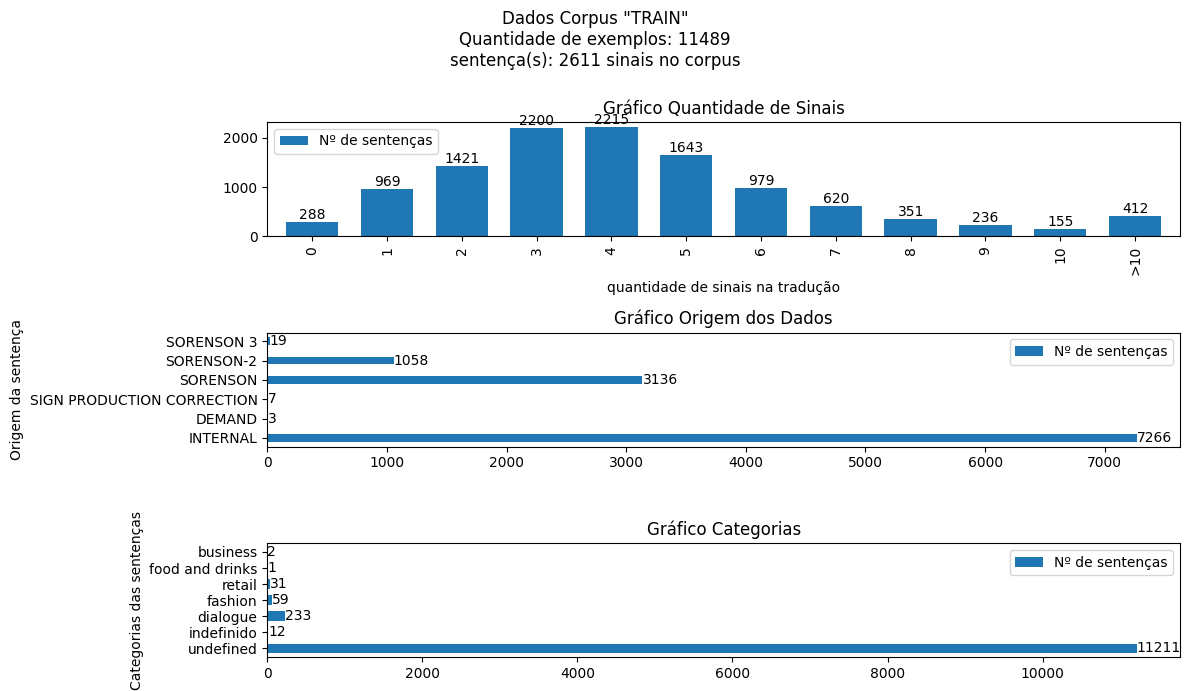

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=1)

w=12
h=50

max = 10
count_dic = dict.fromkeys([str(i) for i in range(max+1)], 0)
count_dic['>' + str(max)] = 0

for _, _, trg, *_ in corpus_data:
    _len = len(list(filter(lambda s: '¶' in s, trg)))
    k = str(_len) if _len <= max else '>' + str(max)
    count_dic[k] += 1

df = pd.DataFrame(count_dic.items(), columns=['quantidade de sinais na tradução', 'Nº de sentenças'])
ax = df.plot(title='Gráfico Quantidade de Sinais', ax=axes[0], x=df.columns[0], kind='bar', figsize=(w, h), width=.7)
ax.bar_label(ax.containers[0])
ax.legend(loc='upper left')

df.to_csv(os.path.join(local_path, f'amount_signs_{TARGET_LANGUAGE.lower()}.csv'), index=False)

####################################
origins = {}

for video_id, *_ in corpus_data:
    origin = videos_coll[video_id].sentence_origin
    if origin in origins:
        origins[origin] += 1
    else:
        origins[origin] = 1

df = pd.DataFrame(origins.items(), columns=['Origem da sentença', 'Nº de sentenças'])
ax = df.plot(title='Gráfico Origem dos Dados', ax=axes[1], x=df.columns[0], kind='barh', figsize=(w, len(origins)),
             width=.4)
ax.bar_label(ax.containers[0])

df.to_csv(os.path.join(local_path, f'origins_{TARGET_LANGUAGE.lower()}.csv'), index=False)

####################################
categories = {}

for video_id, *_ in corpus_data:
    category = videos_coll[video_id].sentence_category

    if not category:
        category = ['?']

    for c in category:
        if c in categories:
            categories[c] += 1
        else:
            categories[c] = 1

df = pd.DataFrame(categories.items(), columns=['Categorias das sentenças', 'Nº de sentenças'])
ax = df.plot(title='Gráfico Categorias', ax=axes[2], x=df.columns[0], kind='barh', figsize=(w, len(categories)),
             width=.6)
ax.bar_label(ax.containers[0])

df.to_csv(os.path.join(local_path, f'categories_{TARGET_LANGUAGE.lower()}.csv'), index=False)
####################################

plt.suptitle(f'Dados Corpus "{GROUP}"\nQuantidade de exemplos: {len(corpus_data)}\nsentença(s): {validation_report}')#, fontsize=16)# y=.955)
# plt.subplots_adjust(top=.96)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

fig.savefig(fname=os.path.join(local_path, 'about.png'), bbox_inches='tight', transparent=False)

Comparação com a versão anterior

In [ ]:
old_origin_freq = cmt.get_origin_freq_videos(corpus_group=GROUP, limit=20000)
comments.append(f'{len(old_origin_freq)} origens')
print(comments[-1])

🍒 Sys[out] » Total videos 8876 query time 19.56s 
🍒 Progress » 000/100 - [▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱] - 0.00% - 🕜 00:00:19/nan estimated Done! ✅ 
6 origens


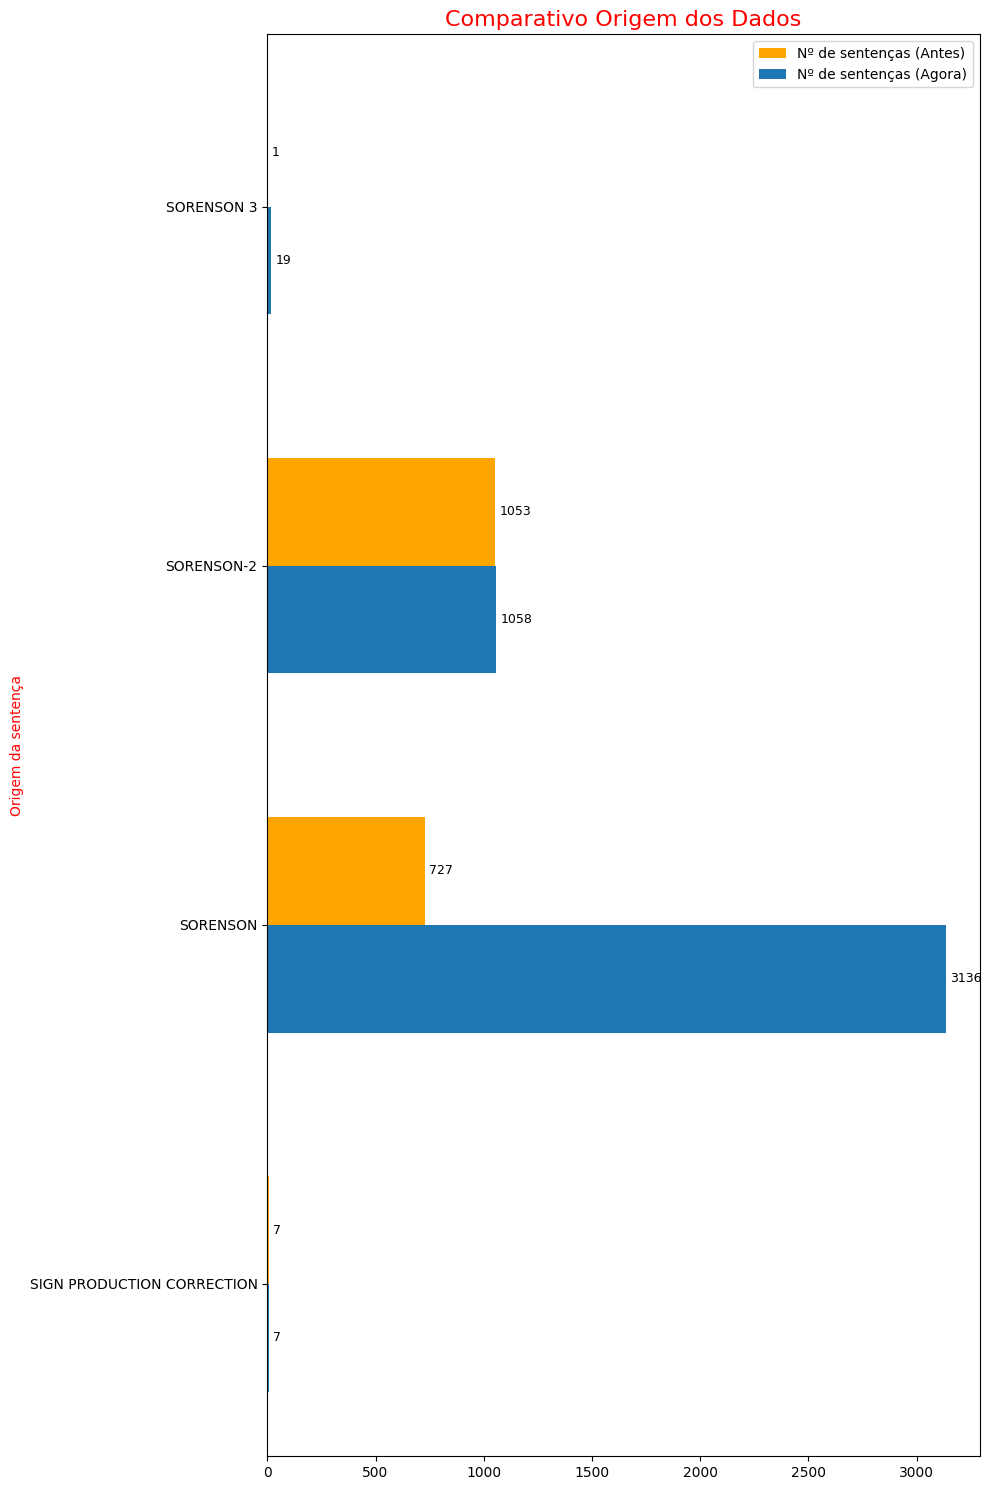

In [ ]:
now_origins_freq = {}
remove_origins = {'INTERNAL', 'UNKNOWN', 'DEMAND'}

for video_id, *_ in corpus_data:
    origin = videos_coll[video_id].sentence_origin

    if origin in remove_origins:
        continue

    if origin in now_origins_freq:
        now_origins_freq[origin] += 1
    else:
        now_origins_freq[origin] = 1

origin_list = []
old_data_list = []
new_data_list = []

for origin, freq in now_origins_freq.items():
    origin_list.append(origin)
    old_data_list.append(old_origin_freq.get(origin, 0))
    new_data_list.append(now_origins_freq[origin])

x = np.arange(len(now_origins_freq))  # the label locations
width = 0.3  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 15))

rects1 = ax.barh(x + width/2, old_data_list, width, label='Nº de sentenças (Antes)', color='orange')
rects2 = ax.barh(x - width/2, new_data_list, width, label='Nº de sentenças (Agora)')

ax.set_ylabel('Origem da sentença', color='red')
ax.set_title('Comparativo Origem dos Dados', fontsize=16, color='red')
# ax.set_xticks(x, origin_list)
ax.set_yticks(x, origin_list)
ax.legend()

ax.bar_label(rects1, padding=3, fontsize=9)
ax.bar_label(rects2, padding=3, fontsize=9)

fig.tight_layout()

plt.show()

fig.savefig(os.path.join(local_path, 'origins_comparation.png'), bbox_inches='tight', transparent=False)

Registro de origens

In [ ]:
origins_count = pd.Series([videos_coll[v_id].sentence_origin for v_id, *_ in corpus_data], name='origin').value_counts()
origins_count

origin
INTERNAL                      7266
SORENSON                      3136
SORENSON-2                    1058
SORENSON 3                      19
SIGN PRODUCTION CORRECTION       7
DEMAND                           3
Name: count, dtype: int64

In [ ]:
origins_count.to_csv(os.path.join(local_path, 'origins_count.csv'))

#### Atualizar Firestore e Storage

<font color='yellow'> ⚠️ Executar apenas quando quiser registrar uma nova versão de Corpus. ⚠️</font>

##### Firestore

⚠️ **<font color='red'>ATENÇÃO!</font>** O Firestore será modificado nesta seção. **Este processo é irreversível.** ⚠️

In [ ]:
query = [('corpusGroup', '==', GROUP),
         ('usedOnTrain', '==', True)]
videos_reset = cmt.list_longer_collection('videos', limit=20000, where_config=query)
print('\n', len(videos_reset))

🍒 Sys[out] » Total videos 8876 query time 26.95s 
🍒 Progress » 000/100 - [▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱] - 0.00% - 🕜 00:00:27/nan estimated Done! ✅ 

 8876


In [ ]:
reset_videos = []
for video_id, video_data in videos_reset.items():
    update = {
        "usedOnTrain": False,
    }
    reset_videos.append((video_data['ref'], update))
len(reset_videos)

8876

In [ ]:
cmt.firestore.update(reset_videos, google_user_num=0) if reset_videos else print('Nada a atualizar')

Usando atualização supervisionada, total 8876 documentos...
🍒 Cereja » 1/1 - [▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰] - 100.00% - 🕜 00:00:00 total - Done! ✅ 
-Atualização proposta: {'usedOnTrain': False}
 Verifique o documento:
 https://console.firebase.google.com/u/0/project/ht-community/firestore/data/workspaces/HT-ASL/videos/gKvz5BA0Txp67oNUYfyA
Digite "s" para continuar)s
🍒 Cereja » 18/18 - [▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰] - 100.00% - 🕜 00:00:37 total - Done! ✅ 


In [ ]:
update_videos = []

for video_id, _, trg, *_ in corpus_data:
    update = {
        "usedOnTrain": True,
    }
    update_videos.append((videos_coll[video_id].reference, update))
len(update_videos)

11489

In [ ]:
update_videos[:2]

[(<google.cloud.firestore_v1.document.DocumentReference at 0x7fb4d8fbf220>,
  {'usedOnTrain': True}),
 (<google.cloud.firestore_v1.document.DocumentReference at 0x7fb4cfd1c220>,
  {'usedOnTrain': True})]

In [ ]:
cmt.firestore.update(update_videos, google_user_num=0)

Usando atualização supervisionada, total 11489 documentos...
🍒 Cereja » 1/1 - [▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰] - 100.00% - 🕜 00:00:00 total - Done! ✅ 
-Atualização proposta: {'usedOnTrain': True}
 Verifique o documento:
 https://console.firebase.google.com/u/0/project/ht-community/firestore/data/workspaces/HT-ASL/videos/kodsBhCJAMULJwmuE7RZ
Digite "s" para continuar)s
🍒 Cereja » 23/23 - [▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰] - 100.00% - 🕜 00:00:48 total - Done! ✅ 


Registrar vídeos que saíram e que entraram no corpus.

In [ ]:
videos_out = set(videos_reset).difference({video_id for video_id, *_ in corpus_data})
videos_in = {video_id for video_id, *_ in corpus_data}.difference(set(videos_reset))
comments.append(f'Número de vídeos que saíram: {len(videos_out)}')
print(comments[-1])
comments.append(f'Número de vídeos que entraram: {len(videos_in)}')
print(comments[-1])

Número de vídeos que saíram: 26
Número de vídeos que entraram: 2639


In [ ]:
with open(os.path.join(local_path, 'videos_out.txt'), 'w') as f:
    f.writelines('\n'.join(sorted(videos_out)))
with open(os.path.join(local_path, 'videos_in.txt'), 'w') as f:
    f.writelines('\n'.join(sorted(videos_in)))

##### Storage

In [ ]:
df_corpus = pd.DataFrame(corpus_data, columns=['document_id', 'source_sentence', 'target_sentence', 'sentence_category', 'client_id'])
df_corpus['target_sentence'] = df_corpus['target_sentence'].apply(lambda l: ' '.join(l))
df_corpus['sentence_category'] = df_corpus['sentence_category'].apply(lambda l: ','.join(l))
df_corpus

,document_id,source_sentence,target_sentence,sentence_category,client_id
0,kodsBhCJAMULJwmuE7RZ,brace yourself,¶qfCLFdByDvWZ7jVig7eo,undefined,HT
1,2KSCVM79d66TXNf1FT5W,two o'clock,¶NvwBPlfYbdWExMtxeR1O,undefined,HT
2,MfD3xBLXDrTB8ssWxMCe,"carter, jimmy",¶21TBko6p5WupZqhgTWoo,undefined,HT
3,nm6RnpgvKA3cY1owBHVi,i'm sorry,¶FPAUUASOmKIaK2dtVGEy ¶Pf3cO3FgUEgDJoV416UW,undefined,HT
4,yZ45LoWmFQUD4tHqR8fY,tobacco,¶YJDaZfFbqCER45bqXUmZ,undefined,HT
...,...,...,...,...,...
11484,2Fr3csyQEaBjIUQuwt2K,run,¶JINEWgsj3MopjzaJRm82,undefined,HT
11485,vgdwt2GrtJLFEWZ8AEBf,point down,¶q1HgD7QIHn4AvmFJ3xDt,undefined,HT
11486,WDJ2tW9bfW5UqW2ng47o,ask me,¶WLeFKNrFFs9enE7bhdH1,undefined,HT
11487,MgRuP2eKXuXd1h67Oxch,questions,¶MMc4R5Iy6rZ0UZKnZ8ZV,undefined,HT


In [ ]:
corpus_name = f'{corpus}_{WORKSPACE.replace("HT-", "").upper()}.csv'
corpus_name

'COMMUNITY_CORPUS_ASL.csv'

In [ ]:
df_corpus.to_csv(os.path.join(local_path, corpus_name), index=False)

In [ ]:
local_path

'/content/data/HT-ASL_community_corpus/'

In [ ]:
#@markdown ___
#@markdown ##### Caso deseje mudar/acrescentar informação ao comentário sobre o corpus `about.txt`
comment_to_add = '' #@param {type:"string"}
if comment_to_add:
    comments.insert(0, comment_to_add)

about = '\n'.join(comments)

print('Comentário do corpus:')
print(about + '\n')

cj.FileIO.create(os.path.join(local_path, 'about.txt'), about).save(exist_ok=True)

Comentário do corpus:
12776 vídeos PROCESSED/VALIDATED usados.
3 vídeos QUARANTINE ~NÃO~ usados.
363 vídeos processados descartados de segmentos não processados
18 sinais para animar
2611 sinais no corpus
2611 sinais glosados
12090/12409 sentenças NÃO são somente datilologias
11489/12409 sentenças paralelas únicas
6 origens
Número de vídeos que saíram: 26
Número de vídeos que entraram: 2639



In [ ]:
date = datetime.today().strftime('%Y-%m-%d')
storage_path = f'corpora/{WORKSPACE}/community/{date}' if GROUP == 'TRAIN' else \
            f'corpora/{WORKSPACE}/validation/{date}'
print('Storage path:', storage_path)

for filename in os.listdir(local_path):
    dest_path = os.path.join(storage_path, filename)
    blob = ml.storage.db.blob(dest_path)

    origin_path = os.path.join(local_path, filename)
    if(os.path.isfile(origin_path)):
        blob.upload_from_filename(origin_path)
        print(f'"{origin_path}" enviado!')
    else:
        print(f'\nIgnorando "{origin_path}"\n')

Storage path: corpora/HT-ASL/community/2024-06-14
"/content/data/HT-ASL_community_corpus/about.png" enviado!
"/content/data/HT-ASL_community_corpus/videos_in.txt" enviado!
"/content/data/HT-ASL_community_corpus/COMMUNITY_CORPUS_ASL.csv" enviado!
"/content/data/HT-ASL_community_corpus/videos_out.txt" enviado!
"/content/data/HT-ASL_community_corpus/ID_GLOSA_ASL.json" enviado!
"/content/data/HT-ASL_community_corpus/amount_signs_asl.csv" enviado!
"/content/data/HT-ASL_community_corpus/origins_comparation.png" enviado!
"/content/data/HT-ASL_community_corpus/origins_asl.csv" enviado!
"/content/data/HT-ASL_community_corpus/categories_asl.csv" enviado!
"/content/data/HT-ASL_community_corpus/about.txt" enviado!
"/content/data/HT-ASL_community_corpus/origins_count.csv" enviado!


### 2. Gerar Corpus Palavras Relacionadas (`related_words`)

Exclusivo para `BZS`. `ASL` aguarda validação dos sinais animados

**Somente se `GROUP == "TRAIN"`**



Filtrar sinais NÃO compostos e validados

Sinais com `pieceOfSign == True` são sinais compostos.

Seguindo [esta atividade](https://www.notion.so/handtalk/Atualizar-flag-warning-nas-cole-es-signs-de-ASL-e-BZS-7f5de7ccd45f4e159cb46c737ff3db5a?pvs=4), sinais com `warning == False` são sinais validados em relação às palavras relacionadas, e podem ser usados na construção deste corpus.

In [21]:
signs_interest = {k: v for k, v in signs_coll.items() if v['pieceOfSign'] == False and v.warning == False}
print(f'{len(signs_interest)}/{len(signs_coll)} sinais NÃO compostos e validados')

450/8494 sinais NÃO compostos e validados


In [22]:
sign_words = {}
for s_id, s_obj in signs_interest.items():
    sign_words[s_id] = set(s_obj['relatedWords'])
len(sign_words)

450

In [23]:
# Apenas o sinal mais frequente persiste na tradução termo -> sinal quando o
# termo existe múltiplas vezes na base.
word_sign_freq = {}

for sign_id, words in sign_words.items():
    for w in words:
        if w in word_sign_freq:
            word_sign_freq[w] = (sign_id,
                                 signs_coll[sign_id].frequency + signs_coll[sign_id].number_of_segments) \
            if signs_coll[sign_id].frequency + signs_coll[sign_id].number_of_segments > word_sign_freq[w][1] \
            else word_sign_freq[w]
        else:
            word_sign_freq[w] = (sign_id, signs_coll[sign_id].frequency + signs_coll[sign_id].number_of_segments)
len(word_sign_freq)

1284

In [24]:
df = pd.DataFrame([(w, f'¶{s}', f) for w, (s, f) in word_sign_freq.items()],
                  columns=['source_sentence', 'target_sentence', 'sign_frequency'])
df

,source_sentence,target_sentence,sign_frequency
0,ohhhhh,¶GgQ60R1FMH19Irdvz5LG,38
1,i see,¶GgQ60R1FMH19Irdvz5LG,38
2,indeed,¶GgQ60R1FMH19Irdvz5LG,38
3,mom,¶udh0T2NlasIdRoHODX5r,292
4,mommy,¶udh0T2NlasIdRoHODX5r,292
...,...,...,...
1279,tried,¶MLzvWDK2hBvK30JMQV20,661
1280,trying,¶MLzvWDK2hBvK30JMQV20,661
1281,distraught,¶f6gEg7JTXj5jL5Tu3T4e,60
1282,sorrows,¶f6gEg7JTXj5jL5Tu3T4e,60


Checando se existem dados duplicados em relação ao source.

In [25]:
duplicated = df.duplicated(subset=['source_sentence']).sum()
print(f'Quantidade de dados duplicados: {duplicated}')

if duplicated:
    print(f'{len(df)} sentenças paralelas antes')
    df = df.drop_duplicates(subset=['source_sentence'], keep='first')
    print(f'{len(df)} sentenças paralelas depois')

Quantidade de dados duplicados: 0


In [26]:
assert df['sign_frequency'].all(), f'Existe sinal com frequência zerada'
print('Todos os sinais possuem frequência válida')

Todos os sinais possuem frequência válida


In [27]:
corpus_name = f'RELATED_WORDS_CORPUS_{TARGET_LANGUAGE}.csv'
corpus_name

'RELATED_WORDS_CORPUS_ASL.csv'

In [28]:
signs_from_corpus = {sign.replace('¶', '') for trg in df['target_sentence']for sign in trg.split(' ') if '¶' in sign}
print(len(signs_from_corpus), 'sinais no corpus')

434 sinais no corpus


In [29]:
assert {sign.replace('¶', '') for trg in df['target_sentence']
        for sign in trg.split(' ') if '¶' in sign}.issubset(signs_coll)
print('Todos os sinais da base existem no Firestore')

Todos os sinais da base existem no Firestore


In [30]:
df.to_csv(corpus_name, index=False)

In [31]:
date = datetime.today().strftime('%Y-%m-%d')
dest_path = f'corpora/{WORKSPACE}/related_words/{date}/{corpus_name}'
blob = ml.storage.db.blob(dest_path)
blob.upload_from_filename(corpus_name)
print(f'corpus salvo em "{dest_path}"')

corpus salvo em "corpora/HT-ASL/related_words/2024-06-21/RELATED_WORDS_CORPUS_ASL.csv"


### Recuperar Dados dos Documentos (legacy)

- Grupo de Treino/Validação
- Que tenham sido verificados ou não tenham sido revisados ainda (`status == ""`)

In [ ]:
query = [('state', 'in', ['', 'VERIFIED']),
         ('corpusGroup', '==', GROUP)]
legacyPD_coll_v = cmt.list_longer_collection('legacyPD', where_config=query,
                                         limit=20000, use_cache=False)
print('\nQuantidade de documentos VERIFIED:', len(legacyPD_coll_v))

query = [('state', '==', 'QUARANTINE'),
         ('corpusGroup', '==', GROUP)]
legacyPD_coll_q = cmt.list_longer_collection('legacyPD', where_config=query,
                                         limit=20000, use_cache=False)
print('\nQuantidade de documentos QUARANTINE:', len(legacyPD_coll_q))

print('\nDestino dos documentos:', GROUP)

🍒 Sys[out] » Total legacyPD 20000 query time 11.31s 
🍒 Sys[out] » Total legacyPD 37846 query time 21.08s 
🍒 Progress » 00:00:20 - Awaiting... 
Quantidade de documentos VERIFIED: 37846
🍒 Sys[out] » Total legacyPD 72 query time 0.17s 
🍒 Progress » 000/100 - [▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱] - 0.00% - 🕜 00:00:00/nan estimated Done! ✅ 

Quantidade de documentos QUARANTINE: 72

Destino dos documentos: TRAIN


In [ ]:
# @title {run: 'auto'}

#@markdown Usar dados em quarentena?
USE_QUARANTINE = False # @param True {type:"boolean"}

if USE_QUARANTINE:
    legacyPD_coll = {**legacyPD_coll_v, **legacyPD_coll_q}
    print("Usando dados em quarentena.")
else:
    legacyPD_coll = legacyPD_coll_v.copy()
    print("Descartando dados em quarentena")

Descartando dados em quarentena


### 3. Gerar Corpus Legado (`legacy` ou `validation_legacy`)
`BZS`/`ASL`

In [ ]:
corpus = {'TRAIN': 'LEGACY_CORPUS',
          'VALIDATION': 'VALIDATION_LEGACY_CORPUS'}[GROUP]

comments = []

local_path = f'{LOCAL_WORK_DIR}/{WORKSPACE}_{corpus.lower()}/'

if os.path.exists(local_path):
    !rm -R '{local_path}'
    print(f'"{local_path}" limpo')

os.makedirs(local_path)
print(f'"{local_path}" criado')

"/content/data/HT-ASL_legacy_corpus/" limpo
"/content/data/HT-ASL_legacy_corpus/" criado


In [ ]:
comments.append(f'{len(legacyPD_coll_v)} documentos VERIFIED ou sem status usados.')
if USE_QUARANTINE:
    comments.append(f'{len(legacyPD_coll_q)} documentos QUARANTINE usados.')
else:
    comments.append(f'{len(legacyPD_coll_q)} documentos QUARANTINE ~NÃO~ usados.')
print(comments)

['37846 documentos VERIFIED ou sem status usados.', '72 documentos QUARANTINE ~NÃO~ usados.']


In [ ]:
print('Destino dos documentos:', GROUP)

Destino dos documentos: TRAIN


In [ ]:
assert all([o['corpusGroup'] == GROUP for o in legacyPD_coll.values()])
print('Todos os documentos recuperados pertencem ao grupo escolhido')

Todos os documentos recuperados pertencem ao grupo escolhido


In [ ]:
if USE_QUARANTINE:
    assert all([o['state'] in ['', 'VERIFIED', 'QUARANTINE'] for o in legacyPD_coll.values()])
else:
    assert all([o['state'] in ['', 'VERIFIED'] for o in legacyPD_coll.values()])
print('Todos os documentos recuperados são de state válido')

Todos os documentos recuperados são de state válido


In [ ]:
signs_from_corpus = {sign for o in legacyPD_coll.values() for sign in o['signs'] if sign in signs_coll}
comments.append(f'{len(signs_from_corpus)} sinais no corpus')
print(comments[-1])

3729 sinais no corpus


In [ ]:
query = [('_state', '==', 'ANIMATED')] if GROUP == 'TRAIN' else [('_state', 'in', ['PROMOTED', 'ANIMATED'])]
signs_ok = cmt.list_longer_collection('signs', where_config=query, use_cache=False)

🍒 Progress » 000/100 - [▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱] - 0.00% - 🕜 00:00:21/nan estimated Done! ✅ 
🍒 Sys[out] » Total signs 8494 query time 21.21s 
🍒 Progress » 000/100 - [▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱] - 0.00% - 🕜 00:00:21/nan estimated Done! ✅ 

In [ ]:
assert signs_from_corpus.issubset(signs_ok)
print('Todos os sinais da base estão animados (se treinamento) ou animados/promovidos (se validação)')

Todos os sinais da base estão animados (se treinamento) ou animados/promovidos (se validação)


In [ ]:
corpus_data = []
for doc_ref, doc_obj in Progress.prog(legacyPD_coll.items()):
    # document_id, source_sentence, signs
    corpus_data.append((doc_ref.id, doc_obj['sentence'], ['¶'+s if s in signs_coll else s for s in doc_obj['signs']]))

🍒 Cereja » 37846/37846 - [▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰] - 100.00% - 🕜 00:00:00 total - Done! ✅ 


Amostra dos dados que vão compor o corpus

In [ ]:
corpus_data[:3]

[('KqNRSdveT7R8ZjbC2AZK',
  'she has never lived in india.',
  ['¶2sgalbvR5sr0p0H78pKe',
   '¶Kn4EU56hPiPZ8JBGwLPO',
   '¶Qn58vpsGIJBmkaLujPyX',
   '¶DySegyGxXZpwKCM2L2sz',
   '¶zMpGYUgUuIuTYnxrPPut']),
 ('XkRUaEHQw5WsrkKResGc',
  'i can play the guitar.',
  ['¶EYDIlgj2dqOWRgfuVshq', '¶4zLwz31rvyMnIk9r0McM', '¶9X6Kp9HMn5KMq44vCOqV']),
 ('e8x3b8aiDXipVe7rh1FK',
  "where's my umbrella?",
  ['¶pI8ckXuxnXPRbSY4IijF', '¶4rDsPdQemapqTaoG2G8m', '¶OOVxL5rZwUgJtsV73NDZ'])]

In [ ]:
id_glosa = {'¶'+sign: signs_ok[sign]['glosa'] if signs_ok[sign]['glosa']
            else signs_ok[sign]['relatedWords'][0]
            for sign in signs_from_corpus}
comments.append(f'{len(id_glosa)} sinais glosados')
print(comments[-1])

3729 sinais glosados


In [ ]:
cj.sample(id_glosa, 3)

{'¶5F43mzORq6CGp0Pq7g6n': 'pear',
 '¶wMZtScB4Q2ER7tvlPMRO': 'privilege',
 '¶lziA1RZyEhNUIOe9HpT0': 'flag'}

In [ ]:
cj.FileIO.create(os.path.join(local_path, f'ID_GLOSA_{TARGET_LANGUAGE}.json'),
                 id_glosa, indent=True).save()

#### Dados sobre o corpus

In [ ]:
unique_parallel_sentences = set()
corpus_data_no_duplicates = []
for parallel_data in corpus_data:
    _, src, trg = parallel_data
    src_trg_joined = (src.lower().strip(), ' '.join(trg))
    if src_trg_joined not in unique_parallel_sentences:
        corpus_data_no_duplicates.append(parallel_data)
    unique_parallel_sentences.update({src_trg_joined})

comments.append(f'{len(unique_parallel_sentences)}/{len(corpus_data)} sentenças paralelas únicas')
print(comments[-1])

corpus_data = corpus_data_no_duplicates

37286/37846 sentenças paralelas únicas


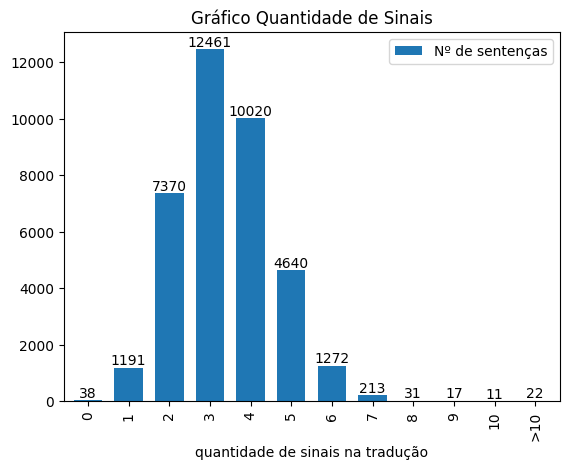

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1)

max = 10
count_dic = dict.fromkeys([str(i) for i in range(max+1)], 0)
count_dic['>' + str(max)] = 0

for _, _, trg in corpus_data:
    _len = len(list(filter(lambda s: '¶' in s, trg)))
    k = str(_len) if _len <= max else '>' + str(max)
    count_dic[k] += 1

df = pd.DataFrame(count_dic.items(), columns=['quantidade de sinais na tradução', 'Nº de sentenças'])
ax = df.plot(title='Gráfico Quantidade de Sinais', ax=axes, x=df.columns[0], kind='bar', width=.7)
ax.bar_label(ax.containers[0])
ax.legend(loc='upper right')

df.to_csv(os.path.join(local_path, f'amount_signs_{TARGET_LANGUAGE.lower()}.csv'), index=False)

#### Atualizar Firestore e Storage

<font color='yellow'> ⚠️ Executar apenas quando quiser registrar uma nova versão de Corpus. ⚠️</font>

##### Firestore

⚠️ **<font color='red'>ATENÇÃO!</font>** O Firestore será modificado nesta seção. **Este processo é irreversível.** ⚠️

In [ ]:
query = [('corpusGroup', '==', GROUP),
         ('usedOnTrain', '==', True)]
legacyPD_reset = cmt.list_longer_collection('legacyPD', limit=20000, where_config=query)
print('\n', len(legacyPD_reset), 'documentos para resetar')

🍒 Sys[out] » Total legacyPD 20000 query time 12.05s 
🍒 Sys[out] » Total legacyPD 37352 query time 21.72s 
🍒 Progress » 000/100 - [▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱] - 0.00% - 🕜 00:00:22/nan estimated Done! ✅ 

 37352 documentos para resetar


In [ ]:
reset_documents = []
for doc_ref, doc_data in legacyPD_reset.items():
    update = {
        "usedOnTrain": False,
    }
    reset_documents.append((doc_ref, update))
len(reset_documents)

37352

In [ ]:
cmt.firestore.update(reset_documents, google_user_num=0) if reset_documents else print('Nada a atualizar')

Usando atualização supervisionada, total 37352 documentos...
🍒 Cereja » 1/1 - [▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰] - 100.00% - 🕜 00:00:00 total - Done! ✅ 
-Atualização proposta: {'usedOnTrain': False}
 Verifique o documento:
 https://console.firebase.google.com/u/0/project/ht-community/firestore/data/workspaces/HT-ASL/legacyPD/KNtB1GAJTSkHmql0oQqA
Digite "s" para continuar)S
🍒 Cereja » 75/75 - [▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰] - 100.00% - 🕜 00:01:06 total - Done! ✅ 


In [ ]:
update_documents = []

lpd_doc_to_ref = {k.id: k for k in legacyPD_coll}

for doc_id, _, _ in corpus_data:
    update = {
        "usedOnTrain": True,
    }
    update_documents.append((lpd_doc_to_ref[doc_id], update))
len(update_documents)

37286

In [ ]:
update_documents[:2]

[(<google.cloud.firestore_v1.document.DocumentReference at 0x7fb4ab9e4a30>,
  {'usedOnTrain': True}),
 (<google.cloud.firestore_v1.document.DocumentReference at 0x7fb4af1a5930>,
  {'usedOnTrain': True})]

In [ ]:
cmt.firestore.update(update_documents, google_user_num=0)

Usando atualização supervisionada, total 37286 documentos...
🍒 Cereja » 1/1 - [▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰] - 100.00% - 🕜 00:00:00 total - Done! ✅ 
-Atualização proposta: {'usedOnTrain': True}
 Verifique o documento:
 https://console.firebase.google.com/u/0/project/ht-community/firestore/data/workspaces/HT-ASL/legacyPD/KqNRSdveT7R8ZjbC2AZK
Digite "s" para continuar)S
🍒 Cereja » 75/75 - [▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰] - 100.00% - 🕜 00:01:05 total - Done! ✅ 


##### Storage

In [ ]:
df_corpus = pd.DataFrame(corpus_data, columns=['document_id', 'source_sentence', 'target_sentence'])
df_corpus['target_sentence'] = df_corpus['target_sentence'].apply(lambda l: ' '.join(l))
df_corpus

,document_id,source_sentence,target_sentence
0,KqNRSdveT7R8ZjbC2AZK,she has never lived in india.,¶2sgalbvR5sr0p0H78pKe ¶Kn4EU56hPiPZ8JBGwLPO ¶Q...
1,XkRUaEHQw5WsrkKResGc,i can play the guitar.,¶EYDIlgj2dqOWRgfuVshq ¶4zLwz31rvyMnIk9r0McM ¶9...
2,e8x3b8aiDXipVe7rh1FK,where's my umbrella?,¶pI8ckXuxnXPRbSY4IijF ¶4rDsPdQemapqTaoG2G8m ¶O...
3,tgZ7TTazt8eCK99NFthv,take care of your back.,¶2OHK1ut2n8yZB7spPnu2 ¶EFKrBfotYiQOQHL0Yk52 ¶Q...
4,dnkoa9ESOIRZqvwbGpZW,i'm sorry i didn't trust you.,¶Pf3cO3FgUEgDJoV416UW ¶4zLwz31rvyMnIk9r0McM ¶n...
...,...,...,...
37281,ZZf6CxkdHrO7631x7Ufh,we just arrived at the station.,¶JQpSxHXG4g5HTKfc4Sim ¶bj02RDl4PeboQzkjLMxX ¶U...
37282,hHBeV21qPplvOsPdRcv9,it's a quarter past nine.,¶6ssoH5RttahIS3nKDpwn 9:15
37283,TTQm2SYz3eSo8ons6Lpd,it's is a quarter past nine.,¶6ssoH5RttahIS3nKDpwn 9:15
37284,YikNHGvSR1pkEqCxofjg,he hasn't eaten for three days.,¶QcbNGtGo2inYxDdkxD6W ¶7AENk3ylp4GKq2pStxYU ¶a...


In [ ]:
corpus_name = f'{corpus}_{WORKSPACE.replace("HT-", "").upper()}.csv'
corpus_name

'LEGACY_CORPUS_ASL.csv'

In [ ]:
df_corpus.to_csv(os.path.join(local_path, corpus_name), index=False)

In [ ]:
local_path

'/content/data/HT-ASL_legacy_corpus/'

In [ ]:
#@markdown ___
#@markdown ##### Caso deseje mudar/acrescentar informação ao comentário sobre o corpus `about.txt`
comment_to_add = "" #@param {type:"string"}
if comment_to_add:
    comments.insert(0, comment_to_add)

about = '\n'.join(comments)

print('Comentário do corpus:')
print(about + '\n')

cj.FileIO.create(os.path.join(local_path, 'about.txt'), about).save(exist_ok=True)

Comentário do corpus:
37846 documentos VERIFIED ou sem status usados.
72 documentos QUARANTINE ~NÃO~ usados.
3729 sinais no corpus
3729 sinais glosados
37286/37846 sentenças paralelas únicas



In [ ]:
date = datetime.today().strftime('%Y-%m-%d')
storage_path = f'corpora/{WORKSPACE}/legacy/{date}' if GROUP == 'TRAIN' else \
            f'corpora/{WORKSPACE}/validation_legacy/{date}'
print('Storage path:', storage_path)

for filename in os.listdir(local_path):
    dest_path = os.path.join(storage_path, filename)
    blob = ml.storage.db.blob(dest_path)

    origin_path = os.path.join(local_path, filename)
    if(os.path.isfile(origin_path)):
        blob.upload_from_filename(origin_path)
        print(f'"{origin_path}" enviado!')
    else:
        print(f'\nIgnorando "{origin_path}"\n')

Storage path: corpora/HT-ASL/legacy/2024-06-14
"/content/data/HT-ASL_legacy_corpus/LEGACY_CORPUS_ASL.csv" enviado!
"/content/data/HT-ASL_legacy_corpus/ID_GLOSA_ASL.json" enviado!
"/content/data/HT-ASL_legacy_corpus/amount_signs_asl.csv" enviado!
"/content/data/HT-ASL_legacy_corpus/about.txt" enviado!


## 🔄 Atualizar versões anteriores do Corpus
Nesta seção, sinais/traduções podem ser ajustadas/atualizadas das versões de corpus:
- `validation`

In [ ]:
from datetime import datetime

#@title Escolher versão do corpus {form-width: "30%"}
#@markdown ##### O código foi desenvolvido para atualizar a partir da última versão construída a partir dos vídeos (atualmente `2024-02-16`), que contém somente as traduções iniciais criadas pelo time de Linguística, com ***todos*** os resultados obtidos pelo Teste AB repescagem. Você pode escolher outra versão, mas vai precisar adaptar o código.
version = '2024-02-16' #@param {type:"string"}

### 4. Atualizar Corpus Community (`validation`)

`BZS`

**Essa seção só precisa ser executada caso uniões de sinais tenham sido realizadas, o que implica na exclusão de alguns sinais. Daí os corpora já gerados precisam ser atualizados.**

In [ ]:
corpus = 'validation'

local_path = f'{LOCAL_WORK_DIR}/{WORKSPACE}_{corpus}/'

if os.path.exists(local_path):
    !rm -R '{local_path}'
    print(f'"{local_path}" limpo')

os.makedirs(local_path)
print(f'"{local_path}" criado')

corpus_blobs = get_corpus_filenames(WORKSPACE, corpus=corpus,
                                   version=version, view_blobs=False)
corpus_blobs

"/content/data/HT-BZS_validation/" criado


[<Blob: ht-nmt, corpora/HT-BZS/validation/2024-02-16/ID_GLOSA_BZS.json, 1708105057291012>,
 <Blob: ht-nmt, corpora/HT-BZS/validation/2024-02-16/VALIDATION_CORPUS_BZS.csv, 1708105054935979>,
 <Blob: ht-nmt, corpora/HT-BZS/validation/2024-02-16/about.png, 1708105057028449>,
 <Blob: ht-nmt, corpora/HT-BZS/validation/2024-02-16/about.txt, 1708105058669862>,
 <Blob: ht-nmt, corpora/HT-BZS/validation/2024-02-16/amount_signs_bzs.csv, 1708105055994849>,
 <Blob: ht-nmt, corpora/HT-BZS/validation/2024-02-16/categories_bzs.csv, 1708105058911784>,
 <Blob: ht-nmt, corpora/HT-BZS/validation/2024-02-16/origins_bzs.csv, 1708105058099469>,
 <Blob: ht-nmt, corpora/HT-BZS/validation/2024-02-16/origins_comparation.png, 1708105055762647>,
 <Blob: ht-nmt, corpora/HT-BZS/validation/2024-02-16/origins_count.csv, 1708105055112026>,
 <Blob: ht-nmt, corpora/HT-BZS/validation/2024-02-16/videos_in.txt, 1708105054138144>,
 <Blob: ht-nmt, corpora/HT-BZS/validation/2024-02-16/videos_out.txt, 1708105057840986>]

In [ ]:
for blob in corpus_blobs:
    blob.download_to_filename(os.path.join(local_path, os.path.basename(blob.name)))

In [ ]:
filename = select_filename(local_path, f'VALIDATION_CORPUS_{TARGET_LANGUAGE}.csv')
filename

'/content/data/HT-BZS_validation/VALIDATION_CORPUS_BZS.csv'

In [ ]:
df = pd.read_csv(filename)
df

,document_id,source_sentence,target_sentence,sentence_category,client_id
0,eLZSBX7zCHXKEMbfsWjz,Clique aqui para acessar nossa sala de aula!,¶LrVMTzNbIUIleRayZkTz ¶cXBBoRD18vqs7AYJeAyd ¶8...,"dialogue,education,technology",HT
1,7ySpOjmvRO32s70L7d4C,"Olá, nessas vídeoaulas iremos falar sobre as b...",¶PVSizvQOyj0egbtYFAKa ¶itwgocHVdCZ97qpLoERh ¶T...,"dialogue,education,industries",C650223CD26A4016ADC81616B0DF8A8B
2,hYkZFGOzG0GFQPi51vZY,Curso de Técnico em Internet das Coisas por 32...,¶REJxf7dtx0Vd8PFYRH1q ¶cXBBoRD18vqs7AYJeAyd ¶i...,"education,finance,technology",315017BD2AD94D9696161FF078FA15A8
3,d1ECXP8CtXDBOZ8GZa9C,A LGPD em bibliotecas e a segurança na interne...,LGPD ¶ASzx7jtbpFA7SLuYahvG ¶JLOL1MFbBZeWfXdQvg...,"education,telecommunication,government office",FE2321811A864FDDA0F01F69207FF922
4,xPfEQeRCsOx8EV5AXkrK,ENVIO DO TCC - GESTÃO DE EQUIPES E LOGÍSTICA E...,¶NRo6pIVkz0swEPt8o7lY TCC ¶b5GVER7r1VHuJVOb1LI...,"education,business,transportation and logistics",C0A4566EF9E44454982B875B4D280A40
...,...,...,...,...,...
908,sFn0GdW57J03h0snx4Od,Reclamação de desobediência ao regulamento de ...,¶XdLTsWyTiYqi9K4B0tMD ¶j7PK6JudISSFAh6Wo7pK ¶U...,government office,B2C05827FC7C4358AD6D7500813C90D1
909,fL2weLJDXsmcT9aetk5R,Os valores são pagos pelo Programa Renda Mínim...,PGRFMM ¶cXBBoRD18vqs7AYJeAyd ¶Dh8IK9050EPuRRDd...,government office,B2C05827FC7C4358AD6D7500813C90D1
910,GDTnX64yUwQlJ0UTrfbJ,Ação conjunta da Prefeitura e Estado dispersa ...,¶EfYLbkSOqCRbgsrhPw9v ¶cXBBoRD18vqs7AYJeAyd ¶j...,government office,B2C05827FC7C4358AD6D7500813C90D1
911,N1gJR5El7Mxdd9Ydpe1v,"EMISSÃO DE GUIAS, ATUALIZAÇÕES, IPTU E TAXA DE...",¶VMoT2mSQI2dL7kCPA2wk ¶pjul653Bc8zZGd0gsnJ4 ¶m...,government office,1C8DF87CCC4C4E15AE75CB3EA47CBF70


Remover vídeos deletados.

In [ ]:
videos_col = cmt.list_longer_collection('videos', where_config=[("corpusGroup", "==", "VALIDATION")])
len(videos_col)

🍒 Sys[out] » Total videos 944 query time 2.21s 
🍒 Progress » 000/100 - [▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱] - 0.00% - 🕜 00:00:02/nan estimated 

944

In [ ]:
df = df[df['document_id'].isin(videos_col)]
df

,document_id,source_sentence,target_sentence,sentence_category,client_id
0,eLZSBX7zCHXKEMbfsWjz,Clique aqui para acessar nossa sala de aula!,¶LrVMTzNbIUIleRayZkTz ¶cXBBoRD18vqs7AYJeAyd ¶8...,"dialogue,education,technology",HT
1,7ySpOjmvRO32s70L7d4C,"Olá, nessas vídeoaulas iremos falar sobre as b...",¶PVSizvQOyj0egbtYFAKa ¶itwgocHVdCZ97qpLoERh ¶T...,"dialogue,education,industries",C650223CD26A4016ADC81616B0DF8A8B
2,hYkZFGOzG0GFQPi51vZY,Curso de Técnico em Internet das Coisas por 32...,¶REJxf7dtx0Vd8PFYRH1q ¶cXBBoRD18vqs7AYJeAyd ¶i...,"education,finance,technology",315017BD2AD94D9696161FF078FA15A8
3,d1ECXP8CtXDBOZ8GZa9C,A LGPD em bibliotecas e a segurança na interne...,LGPD ¶ASzx7jtbpFA7SLuYahvG ¶JLOL1MFbBZeWfXdQvg...,"education,telecommunication,government office",FE2321811A864FDDA0F01F69207FF922
4,xPfEQeRCsOx8EV5AXkrK,ENVIO DO TCC - GESTÃO DE EQUIPES E LOGÍSTICA E...,¶NRo6pIVkz0swEPt8o7lY TCC ¶b5GVER7r1VHuJVOb1LI...,"education,business,transportation and logistics",C0A4566EF9E44454982B875B4D280A40
...,...,...,...,...,...
908,sFn0GdW57J03h0snx4Od,Reclamação de desobediência ao regulamento de ...,¶XdLTsWyTiYqi9K4B0tMD ¶j7PK6JudISSFAh6Wo7pK ¶U...,government office,B2C05827FC7C4358AD6D7500813C90D1
909,fL2weLJDXsmcT9aetk5R,Os valores são pagos pelo Programa Renda Mínim...,PGRFMM ¶cXBBoRD18vqs7AYJeAyd ¶Dh8IK9050EPuRRDd...,government office,B2C05827FC7C4358AD6D7500813C90D1
910,GDTnX64yUwQlJ0UTrfbJ,Ação conjunta da Prefeitura e Estado dispersa ...,¶EfYLbkSOqCRbgsrhPw9v ¶cXBBoRD18vqs7AYJeAyd ¶j...,government office,B2C05827FC7C4358AD6D7500813C90D1
911,N1gJR5El7Mxdd9Ydpe1v,"EMISSÃO DE GUIAS, ATUALIZAÇÕES, IPTU E TAXA DE...",¶VMoT2mSQI2dL7kCPA2wk ¶pjul653Bc8zZGd0gsnJ4 ¶m...,government office,1C8DF87CCC4C4E15AE75CB3EA47CBF70


In [ ]:
print('Número de `source_sentences` únicas', len(set(df['source_sentence'])))
print('Número de `target_sentences` únicas', len(set(df['target_sentence'])))

Número de `source_sentences` únicas 913
Número de `target_sentences` únicas 913


Verificar (e corrigir) se tem excesso de espaços em `source`.

In [ ]:
cases = []
for i, ts in enumerate(df['source_sentence']):
    if ts != re.sub(r' +', ' ', ts):
        cases.append(df.iloc[i]['source_sentence'])
print('Quantidade de casos:', len(cases), '\n', '\r'+'\n'.join(cases[:5]))

Quantidade de casos: 0 
 


In [ ]:
df['source_sentence'] = df['source_sentence'].map(lambda s: re.sub(r' +', ' ', s))
for i, ts in enumerate(df['source_sentence']):
    if ts != re.sub(r' +', ' ', ts):
        print(df.iloc[i]['source_sentence'])

Verificar (e corrigir) se tem excesso de espaços em `target`.

In [ ]:
cases = []
for i, ts in enumerate(df['target_sentence']):
    if ts != re.sub(r' +', ' ', ts):
        cases.append(df.iloc[i]['target_sentence'])
print('Quantidade de casos:', len(cases), '\n', '\r'+'\n'.join(cases[:5]))

Quantidade de casos: 0 
 


In [ ]:
df['target_sentence'] = df['target_sentence'].map(lambda s: re.sub(r' +', ' ', s))
for i, ts in enumerate(df['target_sentence']):
    if ts != re.sub(r' +', ' ', ts):
        print(df.iloc[i]['target_sentence'])

Garantir que não tem espaços sobrando no início e final das frases.

In [ ]:
print('Quantidade de casos no source:', sum(df['source_sentence'] != df['source_sentence'].map(str.strip)))
print('Quantidade de casos no target:', sum(df['target_sentence'] != df['target_sentence'].map(str.strip)))

Quantidade de casos no source: 0
Quantidade de casos no target: 0


In [ ]:
df['source_sentence'] = df['source_sentence'].map(str.strip)
df['target_sentence'] = df['target_sentence'].map(str.strip)

Atualizando sinais unidos.

In [ ]:
total_replaced = 0
replaced_target = []

sign_replace['¶ponto'] = '¶lKSmldnpXZg61uC3GNaJ'
sign_replace['¶virgula'] = '¶lKSmldnpXZg61uC3GNaJ'

for i, trg in enumerate(df['target_sentence']):
    trg_replace_list = [sign_replace.get(sign, sign) for sign in trg.split(' ')]
    total_replaced += sum(map(lambda w: w[0] != w[1], zip(trg.split(' '), trg_replace_list)))
    replaced_target.append(' '.join(trg_replace_list))

df['target_sentence'] = replaced_target
print('total de sinais substituídos:', total_replaced)

total de sinais substituídos: 0


In [ ]:
check_duplicate = lambda d: print('Dataset sem duplicação') if all(not i for i in d.duplicated()) else print('Dataset COM duplicação')
get_duplicate = lambda d: [i for i in d.duplicated() if i]

In [ ]:
check_duplicate(df)

Dataset sem duplicação


Quantas traduções tem cada `sentence` nesta versão do corpus?

In [ ]:
df.groupby('source_sentence')['target_sentence'].agg('count').reset_index()['target_sentence'].value_counts()

target_sentence
1    913
Name: count, dtype: int64

Existe alguma `target_sentence` com poucos caracteres? (útil para encontrar traduções registradas erroneamente.)

In [ ]:
df['target_sentence'].map(len).value_counts().sort_index()

target_sentence
43     13
45      1
47      1
48      2
50      1
       ..
406     1
417     3
461     1
470     1
473     1
Name: count, Length: 227, dtype: int64

#### Adicionar Novas Referências *(opcional)*
**Necessário quando for adicionar novos exemplos de tradução (novas referências) ao dataset de validação. Esses dados vêm do teste AB**

In [ ]:
def list_longer_collection_abTestNmt():
    abTestNmt_ref = cmt.collection('abTestNmt')
    abTestNmt_coll = {k.id: v for k, v in cmt.list_longer_collection('abTestNmt', use_cache=False).items()}
    for abt_id in abTestNmt_coll:
        abTestNmt_coll[abt_id]['ratings'] = {k.id: v for k, v in cmt.firestore.query_long_data(abTestNmt_ref.document(abt_id).collection('ratings'), datetime_field_name='createdAt').items()}
    return abTestNmt_coll

In [ ]:
abTestNmt_coll = list_longer_collection_abTestNmt()

🍒 Sys[out] » Total abTestNmt 13 query time 0.24s 
🍒 Sys[out] » Total ratings 790 query time 1.1s 
🍒 Sys[out] » Total ratings 119 query time 0.22s 
🍒 Sys[out] » Total ratings 321 query time 0.38s 
🍒 Sys[out] » Total ratings 879 query time 1.07s 
🍒 Sys[out] » Total ratings 799 query time 0.94s 
🍒 Sys[out] » Total ratings 38 query time 0.14s 
🍒 Sys[out] » Total ratings 4 query time 0.14s 
🍒 Sys[out] » Total ratings 756 query time 0.78s 
🍒 Sys[out] » Total ratings 120 query time 0.21s 
🍒 Sys[out] » Total ratings 136 query time 0.25s 
🍒 Sys[out] » Total ratings 168 query time 0.28s 
🍒 Sys[out] » Total ratings 112 query time 0.21s 
🍒 Sys[out] » Total ratings 482 query time 0.54s 
🍒 Progress » 000/100 - [▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱] - 0.00% - 🕜 00:00:01/nan estimated 

Recuperando as informações dos testes em ordem cronológica.

In [ ]:
abTestNmt_ids = sorted(abTestNmt_coll.keys(), key = lambda x: abTestNmt_coll[x]['createdAt'])
for id in abTestNmt_ids:
    print(id, abTestNmt_coll[id]['createdAt'])

aa6b941807916b8cd210e94ed341b7d5 2023-01-24 15:51:45+00:00
858d8826416c4af0d4bf03b669335681 2023-02-07 16:10:46+00:00
78c5483f3ebb43c717cdfa03771eabd5 2023-02-24 16:03:29+00:00
6aa9b1e74ebc9e4412c6ad49635cfa34 2023-05-05 20:02:48.844000+00:00
b7f1e6380fe80d50386cd7be64f455c2 2023-06-30 16:42:04.051000+00:00
8862473ec8ad1bdd964f061fb1435432 2023-06-30 18:49:11.430000+00:00
348fa8c3edd36046c28e5a816516001c 2023-07-03 13:41:33.500000+00:00
daa04e7bff0048c73d530ed1fb2c2621 2023-08-16 14:45:04.083000+00:00
5e30be191c128555e60061194e643fa9 2023-09-12 15:27:50.303000+00:00
143409ad59fae72695021df9ec8bb4c9 2023-09-25 15:09:08.473000+00:00
cb7c0841610d3e605e76d953a5fe3790 2023-10-25 20:28:00.779000+00:00
3b9941f5799677baf6fd2620226f4fa7 2023-12-06 15:00:29.190000+00:00
f10b3f5e99cb9a942d3a5b5325b9c1ad 2024-01-02 22:28:50.423000+00:00


Coletando todos os resultados dos Testes AB.

In [ ]:
df_ab = []
for id in abTestNmt_ids:
    test = abTestNmt_coll[id]
    ratings = test['ratings']
    ids = []
    sentences = []
    translates = []
    users = []
    scores = []

    for _, ratings_info in ratings.items():
        for user_id, user_info in ratings_info['usersRatings'].items():
            ids.append(id)
            ids.append(id)
            sentences.append(ratings_info['sentence'])
            sentences.append(ratings_info['sentence'])
            translates.append(' '.join(ratings_info['translate_a']))
            translates.append(' '.join(ratings_info['translate_b']))
            users.append(user_id)
            users.append(user_id)
            scores.append(user_info['score_a'])
            scores.append(user_info['score_b'])

    df_ab.append(pd.DataFrame({'id': ids,
                               'sentence': sentences,
                               'translate': translates,
                               'user': users,
                               'score': scores
                               }))

df_ab = pd.concat(df_ab)
df_ab

,id,sentence,translate,user,score
0,aa6b941807916b8cd210e94ed341b7d5,programa de aprendizagem,¶yYOTF07MPmxA8goNqUqW ¶tja7lJGn3mbVhOJjMc1b,wtSDZumxhTSdJu1yefJtsQOvDnl2,2.0
1,aa6b941807916b8cd210e94ed341b7d5,programa de aprendizagem,¶yYOTF07MPmxA8goNqUqW ¶tja7lJGn3mbVhOJjMc1b,wtSDZumxhTSdJu1yefJtsQOvDnl2,2.0
2,aa6b941807916b8cd210e94ed341b7d5,Corra! Temos apenas 5 produtos no estoque.,¶UNk70W6ZBpZLkgGp9tEP ¶wRm4sfnso4YwB7ZXRv4Z ¶G...,wtSDZumxhTSdJu1yefJtsQOvDnl2,2.0
3,aa6b941807916b8cd210e94ed341b7d5,Corra! Temos apenas 5 produtos no estoque.,¶UNk70W6ZBpZLkgGp9tEP ¶uFBnVQrF7tP2a0hCW4As ¶G...,wtSDZumxhTSdJu1yefJtsQOvDnl2,2.0
4,aa6b941807916b8cd210e94ed341b7d5,Aquele desconto que você ama nos seus produtos...,¶UNk70W6ZBpZLkgGp9tEP ¶wRm4sfnso4YwB7ZXRv4Z ¶G...,wtSDZumxhTSdJu1yefJtsQOvDnl2,1.0
...,...,...,...,...,...
3055,f10b3f5e99cb9a942d3a5b5325b9c1ad,Qual a importância do manual de garantia e man...,,xLbsbTPCk2W0QKsdaRcAWMEgNqT2,NaN
3056,f10b3f5e99cb9a942d3a5b5325b9c1ad,"Aprendizagem em gestão, qualidade, atendimento...",¶tja7lJGn3mbVhOJjMc1b ¶gghfPEa11KFK1FjFUo0Y ¶T...,xLbsbTPCk2W0QKsdaRcAWMEgNqT2,3.0
3057,f10b3f5e99cb9a942d3a5b5325b9c1ad,"Aprendizagem em gestão, qualidade, atendimento...",,xLbsbTPCk2W0QKsdaRcAWMEgNqT2,NaN
3058,f10b3f5e99cb9a942d3a5b5325b9c1ad,"Aprendizagem em gestão, qualidade, atendimento...",¶tja7lJGn3mbVhOJjMc1b ¶gghfPEa11KFK1FjFUo0Y ¶T...,6dUCRItmO8SG5TDe8cAQrpkVd9u1,2.0


In [ ]:
df_ab.isna().sum()

id              0
sentence        0
translate       0
user            0
score        4632
dtype: int64

In [ ]:
df_ab = df_ab.dropna()
df_ab.isna().sum()

id           0
sentence     0
translate    0
user         0
score        0
dtype: int64

In [ ]:
df_ab['score'] = df_ab['score'].astype(int)

<ipython-input-128-c0d3a5406cfe>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ab['score'] = df_ab['score'].astype(int)


Caracteres estranhos.

In [ ]:
df_ab[[('\xa0' in sentence or '\u200b' in sentence) for sentence in df_ab['sentence']]]

,id,sentence,translate,user,score
92,aa6b941807916b8cd210e94ed341b7d5,Diretamente no Centro de Apoio ao Trabalho e E...,¶icOYjoEe9nkQKmRAlW2e ¶S7zp5ZPkPyp4XF4KFqnc ¶z...,wtSDZumxhTSdJu1yefJtsQOvDnl2,0
93,aa6b941807916b8cd210e94ed341b7d5,Diretamente no Centro de Apoio ao Trabalho e E...,¶icOYjoEe9nkQKmRAlW2e ¶S7zp5ZPkPyp4XF4KFqnc ¶u...,wtSDZumxhTSdJu1yefJtsQOvDnl2,0
144,aa6b941807916b8cd210e94ed341b7d5,Nova Tracker a partir de: R$ 97.550,tracker ¶VvjPbF6M7fc9PsH2DsPW ¶58wcNJGA2T2Ycni...,wtSDZumxhTSdJu1yefJtsQOvDnl2,1
145,aa6b941807916b8cd210e94ed341b7d5,Nova Tracker a partir de: R$ 97.550,tracker ¶VvjPbF6M7fc9PsH2DsPW ¶58wcNJGA2T2Ycni...,wtSDZumxhTSdJu1yefJtsQOvDnl2,1
180,858d8826416c4af0d4bf03b669335681,Os preços podem variar de acordo com o seu Est...,¶l7Yvvyv1HY86JZkrDgoF ¶RL0bbatY1mWDqRbgCLk5 ¶k...,muoALSPRGxRQijjqUFa54vPJALi1,0
...,...,...,...,...,...
2793,6aa9b1e74ebc9e4412c6ad49635cfa34,Declaro que li e concordo com todos os termos ...,¶xBShmfmwEwVmELEn2C6Y ¶785Lv70dlLO86c3wwhbz ¶m...,muoALSPRGxRQijjqUFa54vPJALi1,1
2858,6aa9b1e74ebc9e4412c6ad49635cfa34,RELATÓRIOS DE AUDITORIA INTERNA - 2017.,¶O69YGGskYKm1hLvCWUoF ¶u6I3HwE02eSZbLEC8etH ¶A...,eN4xkMlwkzSXteUsdOLtFGMbKo82,2
2859,6aa9b1e74ebc9e4412c6ad49635cfa34,RELATÓRIOS DE AUDITORIA INTERNA - 2017.,¶O69YGGskYKm1hLvCWUoF ¶ASzx7jtbpFA7SLuYahvG ¶A...,eN4xkMlwkzSXteUsdOLtFGMbKo82,0
2860,6aa9b1e74ebc9e4412c6ad49635cfa34,RELATÓRIOS DE AUDITORIA INTERNA - 2017.,¶O69YGGskYKm1hLvCWUoF ¶u6I3HwE02eSZbLEC8etH ¶A...,muoALSPRGxRQijjqUFa54vPJALi1,3


In [ ]:
df_ab['sentence'] = df_ab['sentence'].map(lambda s: re.sub('\xa0', ' ', s))
df_ab['sentence'] = df_ab['sentence'].map(lambda s: re.sub('\u200b', ' ', s))

<ipython-input-130-3053ed4d94ee>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ab['sentence'] = df_ab['sentence'].map(lambda s: re.sub('\xa0', ' ', s))
<ipython-input-130-3053ed4d94ee>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ab['sentence'] = df_ab['sentence'].map(lambda s: re.sub('\u200b', ' ', s))


Verificar (e corrigir) se tem excesso de espaços em `source`.

In [ ]:
cases = []
for i, ts in enumerate(df_ab['sentence']):
    if ts != re.sub(r' +', ' ', ts):
        cases.append(df_ab.iloc[i]['sentence'])
print('Quantidade de casos:', len(cases), '\n', '\r'+'\n'.join(cases[:5]))

Quantidade de casos: 88 
Aquele desconto que você ama nos seus produtos favoritos!  Venda até 50% OFF.
Aquele desconto que você ama nos seus produtos favoritos!  Venda até 50% OFF.
Suas compras  podem ser parceladas em até 12x sem juros no cartão.
Suas compras  podem ser parceladas em até 12x sem juros no cartão.
Cumprimento de Sentença contra Fazenda Pública  Nº 5000524-55.2019(Processo Eletrônico - E-Proc V2 RS)


In [ ]:
df_ab['sentence'] = df_ab['sentence'].map(lambda s: re.sub(r' +', ' ', s))
for i, ts in enumerate(df_ab['sentence']):
    if ts != re.sub(r' +', ' ', ts):
        print(df_ab.iloc[i]['sentence'])

<ipython-input-132-ca8b1a91d00a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ab['sentence'] = df_ab['sentence'].map(lambda s: re.sub(r' +', ' ', s))


Verificar (e corrigir) se tem excesso de espaços em `translate`.

In [ ]:
cases = []
for i, ts in enumerate(df_ab['translate']):
    if ts != re.sub(r' +', ' ', ts):
        cases.append(df_ab.iloc[i]['translate'])
print('Quantidade de casos:', len(cases), '\n', '\r'+'\n'.join(cases[:5]))

Quantidade de casos: 296 
¶SwVSzHGvr2VvJSv7nkRT ¶Lx634BiiWDaqlCuW9aov ¶RhUmg1264QsIqXGRXgij ¶3w6qpbImmBUKa8EYHJ0q ¶LsIIWRxgc4N356prda7v ¶1WCla4aAROazAR1vdZ4g 1 nissan  ¶ponto 
1 ¶LoiFpmBchfgoSQTBuuON ¶2MSDIpkXwQ31uVQuLilD ¶a0zP0ux4sPDPGhKG8pEn ¶yYOTF07MPmxA8goNqUqW ¶rqXs9lr3E4s9awmxdhSS ¶0wapz4A8pBqUQAsQbIoQ ¶0dFN0mvADWDXVSudzOVV  ¶ponto 
¶ZkK5I7i7vbHTZ6uL5hiK ¶F8ibzfTKidYsp1SGESj3 ¶xrh6tW2qBp4SvdTQv78q ¶U2tqoaGLsYEqStAeISm8 ¶xNVWidyEKSiXIN4CGfrA ¶R7iwa4eS47fuO4DpcEkb ¶zGMXorzTGpoUg6DdIx6F 80 ¶2Sc7nlkl6PoTCwWzXWYS  ¶ponto 
¶ZkK5I7i7vbHTZ6uL5hiK ¶F8ibzfTKidYsp1SGESj3 ¶xrh6tW2qBp4SvdTQv78q ¶uM7FsH3yaRxbGFEUdC1k ¶xrh6tW2qBp4SvdTQv78q ¶U2tqoaGLsYEqStAeISm8 ¶xNVWidyEKSiXIN4CGfrA ¶R7iwa4eS47fuO4DpcEkb ¶6iuWXfXUplr2o4RaZ9eX 80  ¶ponto 
¶Zs4YLFy5SWfPzucIG3pT ¶GNQASghW5ANkGmZMdK8A ¶87KVCcKijyk8b7ClOoUV ¶JYJm5KGfzDtXODwwNcRi ¶R7iwa4eS47fuO4DpcEkb ¶LNyLLz1P1IsoJkK20V6M 21:05 ¶uXOXjFfJ9szSVUY7afYA ¶oG0kjElUNwJzlNP9HQj4 19:05  ¶ponto 


In [ ]:
df_ab['translate'] = df_ab['translate'].map(lambda s: re.sub(r' +', ' ', s))
for i, ts in enumerate(df_ab['translate']):
    if ts != re.sub(r' +', ' ', ts):
        print(df_ab.iloc[i]['translate'])

<ipython-input-134-49c1e63d123a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ab['translate'] = df_ab['translate'].map(lambda s: re.sub(r' +', ' ', s))


Garantir que não tem espaços sobrando no início e final das frases.

In [ ]:
print('Quantidade de casos no source:', sum(df_ab['sentence'] != df_ab['sentence'].map(str.strip)))
print('Quantidade de casos em translate:', sum(df_ab['translate'] != df_ab['translate'].map(str.strip)))

Quantidade de casos no source: 166
Quantidade de casos em translate: 356


In [ ]:
df_ab['sentence'] = df_ab['sentence'].map(str.strip)
df_ab['translate'] = df_ab['translate'].map(str.strip)

<ipython-input-136-21c53d91c676>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ab['sentence'] = df_ab['sentence'].map(str.strip)
<ipython-input-136-21c53d91c676>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ab['translate'] = df_ab['translate'].map(str.strip)


Atualizando sinais unidos.

In [ ]:
total_replaced = 0
replaced_target = []

sign_replace['¶ponto'] = '¶lKSmldnpXZg61uC3GNaJ'
sign_replace['¶virgula'] = '¶lKSmldnpXZg61uC3GNaJ'

for i, trg in enumerate(df_ab['translate']):
    trg_replace_list = [sign_replace.get(sign, sign) for sign in trg.split(' ')]
    total_replaced += sum(map(lambda w: w[0] != w[1], zip(trg.split(' '), trg_replace_list)))
    replaced_target.append(' '.join(trg_replace_list))

df_ab['translate'] = replaced_target
print('total de sinais substituídos em translate:', total_replaced)

total de sinais substituídos em translate: 1836


<ipython-input-137-0776da448ca5>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ab['translate'] = replaced_target


Remover o sinal de ponto `¶lKSmldnpXZg61uC3GNaJ` se aparecer no final das frases.

In [ ]:
cases = []
for sentence in df_ab['translate']:
    if sentence.endswith(sign_replace['¶ponto']):
        cases.append(sentence)
print('Quantidade de casos:', len(cases), '\n', '\r'+'\n'.join(cases[:5]))

Quantidade de casos: 270 
¶SwVSzHGvr2VvJSv7nkRT ¶Lx634BiiWDaqlCuW9aov ¶RhUmg1264QsIqXGRXgij ¶3w6qpbImmBUKa8EYHJ0q ¶LsIIWRxgc4N356prda7v ¶1WCla4aAROazAR1vdZ4g 1 nissan ¶lKSmldnpXZg61uC3GNaJ
1 ¶LoiFpmBchfgoSQTBuuON ¶2MSDIpkXwQ31uVQuLilD ¶a0zP0ux4sPDPGhKG8pEn ¶yYOTF07MPmxA8goNqUqW ¶rqXs9lr3E4s9awmxdhSS ¶0wapz4A8pBqUQAsQbIoQ ¶0dFN0mvADWDXVSudzOVV ¶lKSmldnpXZg61uC3GNaJ
¶ZkK5I7i7vbHTZ6uL5hiK ¶F8ibzfTKidYsp1SGESj3 ¶xrh6tW2qBp4SvdTQv78q ¶U2tqoaGLsYEqStAeISm8 ¶xNVWidyEKSiXIN4CGfrA ¶R7iwa4eS47fuO4DpcEkb ¶zGMXorzTGpoUg6DdIx6F 80 ¶2Sc7nlkl6PoTCwWzXWYS ¶lKSmldnpXZg61uC3GNaJ
¶ZkK5I7i7vbHTZ6uL5hiK ¶F8ibzfTKidYsp1SGESj3 ¶xrh6tW2qBp4SvdTQv78q ¶uM7FsH3yaRxbGFEUdC1k ¶xrh6tW2qBp4SvdTQv78q ¶U2tqoaGLsYEqStAeISm8 ¶xNVWidyEKSiXIN4CGfrA ¶R7iwa4eS47fuO4DpcEkb ¶6iuWXfXUplr2o4RaZ9eX 80 ¶lKSmldnpXZg61uC3GNaJ
¶Zs4YLFy5SWfPzucIG3pT ¶GNQASghW5ANkGmZMdK8A ¶87KVCcKijyk8b7ClOoUV ¶JYJm5KGfzDtXODwwNcRi ¶R7iwa4eS47fuO4DpcEkb ¶LNyLLz1P1IsoJkK20V6M 21:05 ¶uXOXjFfJ9szSVUY7afYA ¶oG0kjElUNwJzlNP9HQj4 19:05 ¶lKSmldnpXZg61uC3GNaJ

In [ ]:
df_ab['translate'] = df_ab['translate'].map(lambda s: re.sub(r' ¶lKSmldnpXZg61uC3GNaJ$', '', s))
for sentence in df_ab['translate']:
    if sentence.endswith(sign_replace['¶ponto']):
        print(sentence)

<ipython-input-139-4cd73f0069e9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ab['translate'] = df_ab['translate'].map(lambda s: re.sub(r' ¶lKSmldnpXZg61uC3GNaJ$', '', s))


In [ ]:
df_ab = df_ab.dropna()
df_ab.isna().sum()

id           0
sentence     0
translate    0
user         0
score        0
dtype: int64

Remover o caractere `.` se aparecer no final das frases.

In [ ]:
cases = []
for sentence in df_ab['translate']:
    if sentence.endswith(' .'):
        cases.append(sentence)
print('Quantidade de casos:', len(cases), '\n', '\r'+'\n'.join(cases[:5]))

Quantidade de casos: 824 
¶DeTNPbNGoEIW1dGdfcG2 nissan ¶RhUmg1264QsIqXGRXgij ¶1KIFXLaLDhagqISWbPRF ¶rqXs9lr3E4s9awmxdhSS ¶1WCla4aAROazAR1vdZ4g ¶0oKifiMLE1F016K65a0T ¶VxxYSnd3NnwEWNWUpE8j .
¶DeTNPbNGoEIW1dGdfcG2 nissan ¶1KIFXLaLDhagqISWbPRF ¶UzTIROyjZmgkJ7xjQlnW ¶rqXs9lr3E4s9awmxdhSS ¶1WCla4aAROazAR1vdZ4g ¶0oKifiMLE1F016K65a0T ¶YnVMl6qYezPZdcaLXknl .
¶uvfSOwjKDXQAKJ0ckDWU ¶QOhsZ8zpbXHEg3fQ1vaU ¶9GuKoqVbjPSWTnG9PfcT ¶ko7GCAWe3Y00SAQgTYpd ¶mJrG166Y76EpnPlDTDWf ¶ko7GCAWe3Y00SAQgTYpd ¶G8SC11YlrbGbxzzRJlBK ¶VFGrUiVcyQZLEK6wTrpM ¶4QQrSf5Rnljz0SJXiNh3 ¶954u6RIBpeEfFXktAHWS ¶rqXs9lr3E4s9awmxdhSS ¶R7iwa4eS47fuO4DpcEkb .
¶mJrG166Y76EpnPlDTDWf ¶ko7GCAWe3Y00SAQgTYpd ¶G8SC11YlrbGbxzzRJlBK ¶VFGrUiVcyQZLEK6wTrpM ¶4QQrSf5Rnljz0SJXiNh3 ¶954u6RIBpeEfFXktAHWS ¶R7iwa4eS47fuO4DpcEkb .
¶YdeNgFwXs7Nv4mGvHG7M ¶nA6UskS14bXBEN7frnFP ¶WzU0yhxzyQF2UqagFRDy ¶0wapz4A8pBqUQAsQbIoQ ¶u6I3HwE02eSZbLEC8etH ¶8VtYeAdqQUuucpW7LRg9 .


In [ ]:
df_ab['translate'] = df_ab['translate'].map(lambda s: re.sub(r' \.$', '', s))
for sentence in df_ab['translate']:
    if sentence.endswith(' .'):
        print(sentence)

Remover casos onde `translate` está vazio.

In [ ]:
df_ab[df_ab['translate'] == ""]

,id,sentence,translate,user,score
248,78c5483f3ebb43c717cdfa03771eabd5,Precisamos saber sua localização para mostrar ...,,RvKbgZRytGgLCds5OkEz0MZN4jp2,3
249,78c5483f3ebb43c717cdfa03771eabd5,Precisamos saber sua localização para mostrar ...,,RvKbgZRytGgLCds5OkEz0MZN4jp2,0
250,78c5483f3ebb43c717cdfa03771eabd5,Precisamos saber sua localização para mostrar ...,,eN4xkMlwkzSXteUsdOLtFGMbKo82,0
251,78c5483f3ebb43c717cdfa03771eabd5,Precisamos saber sua localização para mostrar ...,,eN4xkMlwkzSXteUsdOLtFGMbKo82,1
324,78c5483f3ebb43c717cdfa03771eabd5,Apple iPhone 13 (512GB) - Rosa,,RvKbgZRytGgLCds5OkEz0MZN4jp2,0
...,...,...,...,...,...
539,5e30be191c128555e60061194e643fa9,Sandro Ressler inicia 2021 o trabalho na Secre...,,wtSDZumxhTSdJu1yefJtsQOvDnl2,0
541,5e30be191c128555e60061194e643fa9,"Em poucos cliques, você emite certificados par...",,wtSDZumxhTSdJu1yefJtsQOvDnl2,0
543,5e30be191c128555e60061194e643fa9,"Em poucos cliques, você emite certificados par...",,RvKbgZRytGgLCds5OkEz0MZN4jp2,0
305,cb7c0841610d3e605e76d953a5fe3790,QUAIS INFORMAÇÕES SÃO COLETADAS?,,eN4xkMlwkzSXteUsdOLtFGMbKo82,3


In [ ]:
df_ab = df_ab[df_ab['translate'] != ""]
df_ab

,id,sentence,translate,user,score
0,aa6b941807916b8cd210e94ed341b7d5,programa de aprendizagem,¶yYOTF07MPmxA8goNqUqW ¶tja7lJGn3mbVhOJjMc1b,wtSDZumxhTSdJu1yefJtsQOvDnl2,2
1,aa6b941807916b8cd210e94ed341b7d5,programa de aprendizagem,¶yYOTF07MPmxA8goNqUqW ¶tja7lJGn3mbVhOJjMc1b,wtSDZumxhTSdJu1yefJtsQOvDnl2,2
2,aa6b941807916b8cd210e94ed341b7d5,Corra! Temos apenas 5 produtos no estoque.,¶UNk70W6ZBpZLkgGp9tEP ¶wRm4sfnso4YwB7ZXRv4Z ¶G...,wtSDZumxhTSdJu1yefJtsQOvDnl2,2
3,aa6b941807916b8cd210e94ed341b7d5,Corra! Temos apenas 5 produtos no estoque.,¶UNk70W6ZBpZLkgGp9tEP ¶uFBnVQrF7tP2a0hCW4As ¶G...,wtSDZumxhTSdJu1yefJtsQOvDnl2,2
4,aa6b941807916b8cd210e94ed341b7d5,Aquele desconto que você ama nos seus produtos...,¶UNk70W6ZBpZLkgGp9tEP ¶wRm4sfnso4YwB7ZXRv4Z ¶G...,wtSDZumxhTSdJu1yefJtsQOvDnl2,1
...,...,...,...,...,...
3050,f10b3f5e99cb9a942d3a5b5325b9c1ad,Conheça o carro com amplo espaço interno para ...,¶DeTNPbNGoEIW1dGdfcG2 ¶1WCla4aAROazAR1vdZ4g ¶2...,xLbsbTPCk2W0QKsdaRcAWMEgNqT2,2
3052,f10b3f5e99cb9a942d3a5b5325b9c1ad,Qual a importância do manual de garantia e man...,¶f5U0xDqImWSFPXwWB7jp ¶TBFEEAoRsHwmxsy1fouW ¶l...,6dUCRItmO8SG5TDe8cAQrpkVd9u1,2
3054,f10b3f5e99cb9a942d3a5b5325b9c1ad,Qual a importância do manual de garantia e man...,¶f5U0xDqImWSFPXwWB7jp ¶TBFEEAoRsHwmxsy1fouW ¶l...,xLbsbTPCk2W0QKsdaRcAWMEgNqT2,2
3056,f10b3f5e99cb9a942d3a5b5325b9c1ad,"Aprendizagem em gestão, qualidade, atendimento...",¶tja7lJGn3mbVhOJjMc1b ¶gghfPEa11KFK1FjFUo0Y ¶T...,xLbsbTPCk2W0QKsdaRcAWMEgNqT2,3


Votos diferentes do mesmo usuário para o mesmo translate.

In [ ]:
how_many = {'equal': 0, 'not_equal': 0}

tmp = df_ab.groupby(['sentence', 'translate', 'user'])['score'].agg(list).reset_index()
tmp['len'] = tmp['score'].map(len)
for _, row in tmp.iterrows():
    if row['len'] > 1:
        if any(np.diff(row['score'])):
            print(row['user'], row['score'])
            how_many['not_equal'] += 1
        else:
            how_many['equal'] += 1

print(how_many)

eN4xkMlwkzSXteUsdOLtFGMbKo82 [1, 3, 3]
muoALSPRGxRQijjqUFa54vPJALi1 [3, 2, 2]
eN4xkMlwkzSXteUsdOLtFGMbKo82 [2, 0]
xLbsbTPCk2W0QKsdaRcAWMEgNqT2 [1, 2]
RvKbgZRytGgLCds5OkEz0MZN4jp2 [2, 2, 3]
eN4xkMlwkzSXteUsdOLtFGMbKo82 [1, 0]
eN4xkMlwkzSXteUsdOLtFGMbKo82 [1, 1, 0]
eN4xkMlwkzSXteUsdOLtFGMbKo82 [1, 3]
eN4xkMlwkzSXteUsdOLtFGMbKo82 [0, 3]
eN4xkMlwkzSXteUsdOLtFGMbKo82 [2, 1]
eN4xkMlwkzSXteUsdOLtFGMbKo82 [2, 0]
RvKbgZRytGgLCds5OkEz0MZN4jp2 [1, 2]
muoALSPRGxRQijjqUFa54vPJALi1 [2, 1]
RvKbgZRytGgLCds5OkEz0MZN4jp2 [0, 2]
muoALSPRGxRQijjqUFa54vPJALi1 [3, 2]
eN4xkMlwkzSXteUsdOLtFGMbKo82 [2, 3]
RvKbgZRytGgLCds5OkEz0MZN4jp2 [2, 3]
muoALSPRGxRQijjqUFa54vPJALi1 [1, 1, 0]
RvKbgZRytGgLCds5OkEz0MZN4jp2 [2, 3, 2]
muoALSPRGxRQijjqUFa54vPJALi1 [0, 0, 1]
RvKbgZRytGgLCds5OkEz0MZN4jp2 [2, 1]
eN4xkMlwkzSXteUsdOLtFGMbKo82 [1, 1, 0]
eN4xkMlwkzSXteUsdOLtFGMbKo82 [0, 1]
eN4xkMlwkzSXteUsdOLtFGMbKo82 [3, 3, 2, 2]
eN4xkMlwkzSXteUsdOLtFGMbKo82 [1, 2]
eN4xkMlwkzSXteUsdOLtFGMbKo82 [2, 2, 1]
eN4xkMlwkzSXteUsdOLtFGMbKo82 [3

Como cada `translate` será necessariamente avaliado por pelo menos 2 usuários, vamos considerar o valor máximo do score repetido de um mesmo usuário.

In [ ]:
df_ab = df_ab.groupby(['sentence', 'translate', 'user'])['score'].agg(list).reset_index()


In [ ]:
df_ab = df_ab.groupby(['sentence', 'translate', 'user'])['score'].agg(list).reset_index()
df_ab['score'] = df_ab['score'].map(np.max)
df_ab

,sentence,translate,user,score
0,1 produto adicionado à sacola.,1 ¶YbV1sbfbHl5bXifSDNFT ¶OIH9RUn1TFljngHhx9mF ...,6dUCRItmO8SG5TDe8cAQrpkVd9u1,1
1,1 produto adicionado à sacola.,1 ¶YbV1sbfbHl5bXifSDNFT ¶OIH9RUn1TFljngHhx9mF ...,xLbsbTPCk2W0QKsdaRcAWMEgNqT2,2
2,1 produto adicionado à sacola.,1 ¶YbV1sbfbHl5bXifSDNFT ¶xbR2k0BR0qe45R4wFzLI ...,RvKbgZRytGgLCds5OkEz0MZN4jp2,3
3,1 produto adicionado à sacola.,1 ¶YbV1sbfbHl5bXifSDNFT ¶xbR2k0BR0qe45R4wFzLI ...,muoALSPRGxRQijjqUFa54vPJALi1,3
4,1 vaga disponível para assistente de logística...,1 ¶yYoFtYlvRfeuzb6FMFyk ¶YdeNgFwXs7Nv4mGvHG7M ...,RvKbgZRytGgLCds5OkEz0MZN4jp2,1
...,...,...,...,...
12073,Órgão Julgador: Juízo Substituto da 1ª vara de...,¶U9sbSrRhH3iNQywURUTH ¶FvAPnsFgSp7TqMupY0r5 ¶x...,muoALSPRGxRQijjqUFa54vPJALi1,1
12074,Órgão Julgador: Juízo Substituto da 1ª vara de...,¶U9sbSrRhH3iNQywURUTH ¶FvAPnsFgSp7TqMupY0r5 ¶x...,muoALSPRGxRQijjqUFa54vPJALi1,0
12075,Órgão Julgador: Juízo Substituto da 1ª vara de...,¶U9sbSrRhH3iNQywURUTH ¶FvAPnsFgSp7TqMupY0r5 ¶x...,RvKbgZRytGgLCds5OkEz0MZN4jp2,0
12076,Órgão Julgador: Juízo Substituto da 1ª vara de...,¶U9sbSrRhH3iNQywURUTH ¶FvAPnsFgSp7TqMupY0r5 ¶x...,eN4xkMlwkzSXteUsdOLtFGMbKo82,0


Contabilizando número de usuários e score médio.

In [ ]:
df_ab = pd.merge(df_ab.groupby(['sentence', 'translate'])['user'].agg('count').reset_index(),
                 df_ab.groupby(['sentence', 'translate'])['score'].agg(list).reset_index())
df_ab

,sentence,translate,user,score
0,1 produto adicionado à sacola.,1 ¶YbV1sbfbHl5bXifSDNFT ¶OIH9RUn1TFljngHhx9mF ...,2,"[1, 2]"
1,1 produto adicionado à sacola.,1 ¶YbV1sbfbHl5bXifSDNFT ¶xbR2k0BR0qe45R4wFzLI ...,2,"[3, 3]"
2,1 vaga disponível para assistente de logística...,1 ¶yYoFtYlvRfeuzb6FMFyk ¶YdeNgFwXs7Nv4mGvHG7M ...,2,"[1, 2]"
3,1 vaga disponível para assistente de logística...,1 ¶yYoFtYlvRfeuzb6FMFyk ¶YdeNgFwXs7Nv4mGvHG7M ...,2,"[1, 1]"
4,1 vaga disponível para assistente de logística...,1 ¶yYoFtYlvRfeuzb6FMFyk ¶YdeNgFwXs7Nv4mGvHG7M ...,2,"[1, 0]"
...,...,...,...,...
5803,Órgão Julgador: Juízo Substituto da 1ª vara de...,¶GwXBFH1SrP0eZ1Fcj6WO ¶FvAPnsFgSp7TqMupY0r5 ¶x...,2,"[1, 0]"
5804,Órgão Julgador: Juízo Substituto da 1ª vara de...,¶U9sbSrRhH3iNQywURUTH ¶FvAPnsFgSp7TqMupY0r5 ¶x...,2,"[0, 1]"
5805,Órgão Julgador: Juízo Substituto da 1ª vara de...,¶U9sbSrRhH3iNQywURUTH ¶FvAPnsFgSp7TqMupY0r5 ¶x...,2,"[0, 1]"
5806,Órgão Julgador: Juízo Substituto da 1ª vara de...,¶U9sbSrRhH3iNQywURUTH ¶FvAPnsFgSp7TqMupY0r5 ¶x...,1,[0]


Número de votos para cada sentence/translate.

In [ ]:
df_ab['user'].value_counts()

user
2    4893
3     484
1     297
4     127
5       7
Name: count, dtype: int64

Vamos manter como referências somente as frases que têm 2 ou mais votos.

In [ ]:
df_ab = df_ab[df_ab['user'] >= 2]
df_ab

,sentence,translate,user,score
0,1 produto adicionado à sacola.,1 ¶YbV1sbfbHl5bXifSDNFT ¶OIH9RUn1TFljngHhx9mF ...,2,"[1, 2]"
1,1 produto adicionado à sacola.,1 ¶YbV1sbfbHl5bXifSDNFT ¶xbR2k0BR0qe45R4wFzLI ...,2,"[3, 3]"
2,1 vaga disponível para assistente de logística...,1 ¶yYoFtYlvRfeuzb6FMFyk ¶YdeNgFwXs7Nv4mGvHG7M ...,2,"[1, 2]"
3,1 vaga disponível para assistente de logística...,1 ¶yYoFtYlvRfeuzb6FMFyk ¶YdeNgFwXs7Nv4mGvHG7M ...,2,"[1, 1]"
4,1 vaga disponível para assistente de logística...,1 ¶yYoFtYlvRfeuzb6FMFyk ¶YdeNgFwXs7Nv4mGvHG7M ...,2,"[1, 0]"
...,...,...,...,...
5802,Órgão Julgador: Juízo Substituto da 1ª vara de...,¶FvAPnsFgSp7TqMupY0r5 ¶FvAPnsFgSp7TqMupY0r5 ¶x...,2,"[0, 0]"
5803,Órgão Julgador: Juízo Substituto da 1ª vara de...,¶GwXBFH1SrP0eZ1Fcj6WO ¶FvAPnsFgSp7TqMupY0r5 ¶x...,2,"[1, 0]"
5804,Órgão Julgador: Juízo Substituto da 1ª vara de...,¶U9sbSrRhH3iNQywURUTH ¶FvAPnsFgSp7TqMupY0r5 ¶x...,2,"[0, 1]"
5805,Órgão Julgador: Juízo Substituto da 1ª vara de...,¶U9sbSrRhH3iNQywURUTH ¶FvAPnsFgSp7TqMupY0r5 ¶x...,2,"[0, 1]"


Agora filtramos apenas para os translates com pelo menos 2 votos com score 3.

In [ ]:
scores = df_ab[['sentence', 'translate', 'score']]
scores = scores.rename(columns={'sentence': 'source_sentence', 'translate': 'target_sentence', 'score': 'score'})

mask = scores['score'].map(lambda scs: scs.count(3) >= 2)

df_references = scores[mask].drop('score', axis=1).reset_index(drop=True).drop_duplicates()
df_references

,source_sentence,target_sentence
0,1 produto adicionado à sacola.,1 ¶YbV1sbfbHl5bXifSDNFT ¶xbR2k0BR0qe45R4wFzLI ...
1,10 é a Pontuação máxima,10 ¶VfAbbcIPjJJAjVcwAPuj ¶JahVNwZu2mDRIxJLAUXk...
2,10 é a Pontuação máxima,10 ¶t5QZ6LeRtMvNMxTpTNwY ¶1HKbeVDdpoxo8zL9dTmi
3,12 Ecolapis de Cor Bicolor Kit Escolar = 24 Co...,12 ecolapis ¶0LxC069AKzpgnaSDc25n bicolor ¶xL9...
4,"2ª via de fatura, contas pagas, conta por e-ma...",¶mCZhSv8h0rHtfVA1SZIN via ¶2KCd6EDYMsS4idZ2iN3...
...,...,...
396,Você pode pedir o aumento de limite do seu car...,¶G8SC11YlrbGbxzzRJlBK ¶tlcIPrrQrbMGYo1x6old ¶S...
397,"Voltar ao curso, exibir todas as tentativas, i...",¶REJxf7dtx0Vd8PFYRH1q ¶jIImKck8mToD3CYzoqsx ¶d...
398,"Voltar ao curso, exibir todas as tentativas, i...",¶jIImKck8mToD3CYzoqsx ¶REJxf7dtx0Vd8PFYRH1q ¶d...
399,"Voltar ao curso, exibir todas as tentativas, i...",¶jIImKck8mToD3CYzoqsx ¶REJxf7dtx0Vd8PFYRH1q ¶d...


In [ ]:
check_duplicate(df_references)

Dataset sem duplicação


⚠️ Para adicionar as novas referências à versão revisada da Base de Validação (dados do Firestore depois de SET/2023), é preciso fazer uma adequação em `source_sentence`, alterando para sua versão corrigida pelo ChatGPT, para compatibilidade com a versão revisada.

👇👇👇

In [ ]:
import json

from google.colab import drive
drive.mount('/content/drive')

with open('drive/Shareddrives/IA/CIENCIA_DE_DADOS/PROCESSOS/TESTE_AB/sentence_dict.json', encoding='utf-8') as f:
    sentence_dict = json.load(f)
cj.sample(sentence_dict, 5)

Mounted at /content/drive


{'10 é a Pontuação máxima': '10 é a pontuação máxima.',
 '12 Ecolapis de Cor Bicolor Kit Escolar = 24 Cores + 2 Grafite.': '12 Ecolápis de Cor Bicolor Kit Escolar = 24 cores + 2 Grafite.',
 '16/04/2021 09:59 - 131. Processo Suspenso ou Sobrestado por decisão judicial - Aguarda decisão da instância superior': '16/04/2021 09:59 - 131. Processo Suspenso ou Sobrestado por decisão judicial - Aguarda decisão da instância superior.',
 'A LGPD em bibliotecas e a segurança na internet para crianças e adolescentes são abordadas durante palestra on-line.': 'A LGPD em bibliotecas e a segurança na internet para crianças e adolescentes são abordadas durante palestra online.',
 'A embalagem é reutilizável e 100% reciclável e a tinta é lavável e atóxica.': 'A embalagem é reutilizável e 100% reciclável, e a tinta é lavável e atóxica.'}

In [ ]:
source_sentences = df_references['source_sentence'].tolist()
source_sentences_corr = []
count = 0
for sentence in source_sentences:
    if sentence in sentence_dict:
        source_sentences_corr.append(sentence_dict[sentence])
        count += 1
    else:
        source_sentences_corr.append(sentence)
print(count)
source_sentences_corr[:5]

69


['1 produto adicionado à sacola.',
 '10 é a pontuação máxima.',
 '10 é a pontuação máxima.',
 '12 Ecolápis de Cor Bicolor Kit Escolar = 24 cores + 2 Grafite.',
 '2ª via de fatura, contas pagas, conta por e-mail e outros.']

In [ ]:
df_references['source_sentence'] = source_sentences_corr

☝️☝️☝️

Checar se alguma frase dos Testes AB não tem correspondente no dataset original.

In [ ]:
df_references.merge(df, how='left', on=['source_sentence'], suffixes=(None, '_original'), indicator=True).query('_merge == "left_only"')

,source_sentence,target_sentence,document_id,target_sentence_original,sentence_category,client_id,_merge
14,A experiência da aula presencial dentro da sua...,¶kcqxvXpSGZVzRd63Mtnh ¶R7iwa4eS47fuO4DpcEkb ¶Y...,NaN,NaN,NaN,NaN,left_only
36,Apple iPhone 13 mini (512GB) Estelar,¶8XdUQuzDvaeQ5Da2i7SR ¶A9loxyaG5bUVmYWITsPD ¶u...,NaN,NaN,NaN,NaN,left_only
99,Compre sua passagem.,¶1KIFXLaLDhagqISWbPRF ¶gC1jHvHpzBBE01YadmS5 ¶r...,NaN,NaN,NaN,NaN,left_only
110,Conheça nossa Política de Privacidade.,¶DeTNPbNGoEIW1dGdfcG2 ¶TpAGr6P1Ycsbk6vC1yR8 ¶u...,NaN,NaN,NaN,NaN,left_only
128,"Cursos rápidos de iniciação, aperfeiçoamento e...",¶REJxf7dtx0Vd8PFYRH1q ¶XSajj9aV2RakNfbDeFSf ¶5...,NaN,NaN,NaN,NaN,left_only
130,Descreva os parâmetros no uso de Libras.,¶JeIFqFtLql5WjcUUdye2 ¶I1Rwh2oGc8zShH4spdeU ¶a...,NaN,NaN,NaN,NaN,left_only
141,Documentação Trabalhadores da Educação Básica ...,¶nA6UskS14bXBEN7frnFP ¶ZkK5I7i7vbHTZ6uL5hiK ¶R...,NaN,NaN,NaN,NaN,left_only
142,Documentação para Trabalhadores da Educação Bá...,¶nA6UskS14bXBEN7frnFP ¶qbp7p1I0d1VYXs4Yo0Tw ¶R...,NaN,NaN,NaN,NaN,left_only
145,ESPECIFICAÇÕES,¶irZuL5eIBCZezEsNwRfB ¶8NDRJQJRqeapTckJJhi4,NaN,NaN,NaN,NaN,left_only
152,Emissão de Guias,¶YdeNgFwXs7Nv4mGvHG7M ¶z1aQL7uxV1RAqPP0pUWn,NaN,NaN,NaN,NaN,left_only


Recuperando as informações dos vídeos para as novas referências.

In [ ]:
df_new_refs = df_references.merge(df, how='inner', on=['source_sentence'], suffixes=(None, '_original'))[['document_id', 'source_sentence', 'target_sentence', 'sentence_category', 'client_id']]
df_new_refs

,document_id,source_sentence,target_sentence,sentence_category,client_id
0,KMNHiefdyk27yhQhjzqN,1 produto adicionado à sacola.,1 ¶YbV1sbfbHl5bXifSDNFT ¶xbR2k0BR0qe45R4wFzLI ...,retail,6EA5497F124449D2876EE4CC042B21FA
1,LGhahxTZUYXp5sqmMt2L,10 é a pontuação máxima.,10 ¶VfAbbcIPjJJAjVcwAPuj ¶JahVNwZu2mDRIxJLAUXk...,education,C0A4566EF9E44454982B875B4D280A40
2,LGhahxTZUYXp5sqmMt2L,10 é a pontuação máxima.,10 ¶t5QZ6LeRtMvNMxTpTNwY ¶1HKbeVDdpoxo8zL9dTmi,education,C0A4566EF9E44454982B875B4D280A40
3,uGyd76bWkRDk91Q0fEuV,12 Ecolápis de Cor Bicolor Kit Escolar = 24 co...,12 ecolapis ¶0LxC069AKzpgnaSDc25n bicolor ¶xL9...,retail,32D707AA813949DF8CF8683679832CBB
4,mtzXMcejD9VvWxAMVUEl,"2ª via de fatura, contas pagas, conta por e-ma...",¶mCZhSv8h0rHtfVA1SZIN via ¶2KCd6EDYMsS4idZ2iN3...,finance,EB3C4D4A58A543F0BA8310E5976A3BC6
...,...,...,...,...,...
369,miDMcKEiv3tW0vIcZ1O8,Você pode pedir o aumento de limite do seu car...,¶G8SC11YlrbGbxzzRJlBK ¶tlcIPrrQrbMGYo1x6old ¶S...,"finance,business",B196E8DB235D42EBA02A8985B903C461
370,3cMOPhHIZnvIorNbL1FO,"Voltar ao curso, exibir todas as tentativas, i...",¶REJxf7dtx0Vd8PFYRH1q ¶jIImKck8mToD3CYzoqsx ¶d...,"education,software",9A96F1EB9CA742C780B3E3F0C2205726
371,3cMOPhHIZnvIorNbL1FO,"Voltar ao curso, exibir todas as tentativas, i...",¶jIImKck8mToD3CYzoqsx ¶REJxf7dtx0Vd8PFYRH1q ¶d...,"education,software",9A96F1EB9CA742C780B3E3F0C2205726
372,3cMOPhHIZnvIorNbL1FO,"Voltar ao curso, exibir todas as tentativas, i...",¶jIImKck8mToD3CYzoqsx ¶REJxf7dtx0Vd8PFYRH1q ¶d...,"education,software",9A96F1EB9CA742C780B3E3F0C2205726


In [ ]:
print(len(set(df_new_refs['document_id'])), 'vídeos diferentes')

267 vídeos diferentes


In [ ]:
check_duplicate(df_new_refs)

Dataset sem duplicação


Juntando as novas referências com as referências originais.

In [ ]:
df = pd.concat([df, df_new_refs], ignore_index=True)
df

,document_id,source_sentence,target_sentence,sentence_category,client_id
0,eLZSBX7zCHXKEMbfsWjz,Clique aqui para acessar nossa sala de aula!,¶LrVMTzNbIUIleRayZkTz ¶cXBBoRD18vqs7AYJeAyd ¶8...,"dialogue,education,technology",HT
1,7ySpOjmvRO32s70L7d4C,"Olá, nessas vídeoaulas iremos falar sobre as b...",¶PVSizvQOyj0egbtYFAKa ¶itwgocHVdCZ97qpLoERh ¶T...,"dialogue,education,industries",C650223CD26A4016ADC81616B0DF8A8B
2,hYkZFGOzG0GFQPi51vZY,Curso de Técnico em Internet das Coisas por 32...,¶REJxf7dtx0Vd8PFYRH1q ¶cXBBoRD18vqs7AYJeAyd ¶i...,"education,finance,technology",315017BD2AD94D9696161FF078FA15A8
3,d1ECXP8CtXDBOZ8GZa9C,A LGPD em bibliotecas e a segurança na interne...,LGPD ¶ASzx7jtbpFA7SLuYahvG ¶JLOL1MFbBZeWfXdQvg...,"education,telecommunication,government office",FE2321811A864FDDA0F01F69207FF922
4,xPfEQeRCsOx8EV5AXkrK,ENVIO DO TCC - GESTÃO DE EQUIPES E LOGÍSTICA E...,¶NRo6pIVkz0swEPt8o7lY TCC ¶b5GVER7r1VHuJVOb1LI...,"education,business,transportation and logistics",C0A4566EF9E44454982B875B4D280A40
...,...,...,...,...,...
1282,miDMcKEiv3tW0vIcZ1O8,Você pode pedir o aumento de limite do seu car...,¶G8SC11YlrbGbxzzRJlBK ¶tlcIPrrQrbMGYo1x6old ¶S...,"finance,business",B196E8DB235D42EBA02A8985B903C461
1283,3cMOPhHIZnvIorNbL1FO,"Voltar ao curso, exibir todas as tentativas, i...",¶REJxf7dtx0Vd8PFYRH1q ¶jIImKck8mToD3CYzoqsx ¶d...,"education,software",9A96F1EB9CA742C780B3E3F0C2205726
1284,3cMOPhHIZnvIorNbL1FO,"Voltar ao curso, exibir todas as tentativas, i...",¶jIImKck8mToD3CYzoqsx ¶REJxf7dtx0Vd8PFYRH1q ¶d...,"education,software",9A96F1EB9CA742C780B3E3F0C2205726
1285,3cMOPhHIZnvIorNbL1FO,"Voltar ao curso, exibir todas as tentativas, i...",¶jIImKck8mToD3CYzoqsx ¶REJxf7dtx0Vd8PFYRH1q ¶d...,"education,software",9A96F1EB9CA742C780B3E3F0C2205726


In [ ]:
check_duplicate(df)

Dataset COM duplicação


In [ ]:
# Casos duplicados
df[df.duplicated(keep=False) == True].sort_values('document_id')

,document_id,source_sentence,target_sentence,sentence_category,client_id
55,3cMOPhHIZnvIorNbL1FO,"Voltar ao curso, exibir todas as tentativas, i...",¶jIImKck8mToD3CYzoqsx ¶REJxf7dtx0Vd8PFYRH1q ¶d...,"education,software",9A96F1EB9CA742C780B3E3F0C2205726
1284,3cMOPhHIZnvIorNbL1FO,"Voltar ao curso, exibir todas as tentativas, i...",¶jIImKck8mToD3CYzoqsx ¶REJxf7dtx0Vd8PFYRH1q ¶d...,"education,software",9A96F1EB9CA742C780B3E3F0C2205726
713,DVCpQqojkS5LMbpvRsO1,Informações sobre o produto.,¶OuRerhnZYfLudn92mnLk ¶GLRZxOzm3pLq4oqd2SyK ¶Y...,retail,32D707AA813949DF8CF8683679832CBB
1095,DVCpQqojkS5LMbpvRsO1,Informações sobre o produto.,¶OuRerhnZYfLudn92mnLk ¶GLRZxOzm3pLq4oqd2SyK ¶Y...,retail,32D707AA813949DF8CF8683679832CBB
131,Gm7dz8igSA708FdRZz5d,Instrutor de curso,¶dsNipew8780ByZqeRBSg ¶REJxf7dtx0Vd8PFYRH1q,education,24C638A27EAC4604BEDF252785DE0578
1098,Gm7dz8igSA708FdRZz5d,Instrutor de curso,¶dsNipew8780ByZqeRBSg ¶REJxf7dtx0Vd8PFYRH1q,education,24C638A27EAC4604BEDF252785DE0578
294,zVkwKmWnwYztZZjlFUap,Valor das parcelas,¶l7Yvvyv1HY86JZkrDgoF ¶Lmu3a8m0j8Zsgj28ZCBi,"finance,retail",786ACC4B56FB439DAC20400E54DC6D83
1264,zVkwKmWnwYztZZjlFUap,Valor das parcelas,¶l7Yvvyv1HY86JZkrDgoF ¶Lmu3a8m0j8Zsgj28ZCBi,"finance,retail",786ACC4B56FB439DAC20400E54DC6D83


In [ ]:
# Remove duplicações
df = df[df.duplicated() == False]
df

,document_id,source_sentence,target_sentence,sentence_category,client_id
0,eLZSBX7zCHXKEMbfsWjz,Clique aqui para acessar nossa sala de aula!,¶LrVMTzNbIUIleRayZkTz ¶cXBBoRD18vqs7AYJeAyd ¶8...,"dialogue,education,technology",HT
1,7ySpOjmvRO32s70L7d4C,"Olá, nessas vídeoaulas iremos falar sobre as b...",¶PVSizvQOyj0egbtYFAKa ¶itwgocHVdCZ97qpLoERh ¶T...,"dialogue,education,industries",C650223CD26A4016ADC81616B0DF8A8B
2,hYkZFGOzG0GFQPi51vZY,Curso de Técnico em Internet das Coisas por 32...,¶REJxf7dtx0Vd8PFYRH1q ¶cXBBoRD18vqs7AYJeAyd ¶i...,"education,finance,technology",315017BD2AD94D9696161FF078FA15A8
3,d1ECXP8CtXDBOZ8GZa9C,A LGPD em bibliotecas e a segurança na interne...,LGPD ¶ASzx7jtbpFA7SLuYahvG ¶JLOL1MFbBZeWfXdQvg...,"education,telecommunication,government office",FE2321811A864FDDA0F01F69207FF922
4,xPfEQeRCsOx8EV5AXkrK,ENVIO DO TCC - GESTÃO DE EQUIPES E LOGÍSTICA E...,¶NRo6pIVkz0swEPt8o7lY TCC ¶b5GVER7r1VHuJVOb1LI...,"education,business,transportation and logistics",C0A4566EF9E44454982B875B4D280A40
...,...,...,...,...,...
1281,wkueeFAdywuA6V90XTdJ,Você paga qualquer valor da sua fatura em qual...,¶G8SC11YlrbGbxzzRJlBK ¶9mxWQZH8t4slKzqcOTBm ¶l...,finance,B196E8DB235D42EBA02A8985B903C461
1282,miDMcKEiv3tW0vIcZ1O8,Você pode pedir o aumento de limite do seu car...,¶G8SC11YlrbGbxzzRJlBK ¶tlcIPrrQrbMGYo1x6old ¶S...,"finance,business",B196E8DB235D42EBA02A8985B903C461
1283,3cMOPhHIZnvIorNbL1FO,"Voltar ao curso, exibir todas as tentativas, i...",¶REJxf7dtx0Vd8PFYRH1q ¶jIImKck8mToD3CYzoqsx ¶d...,"education,software",9A96F1EB9CA742C780B3E3F0C2205726
1285,3cMOPhHIZnvIorNbL1FO,"Voltar ao curso, exibir todas as tentativas, i...",¶jIImKck8mToD3CYzoqsx ¶REJxf7dtx0Vd8PFYRH1q ¶d...,"education,software",9A96F1EB9CA742C780B3E3F0C2205726


In [ ]:
df[df['document_id'].duplicated(keep=False) == True].sort_values('document_id')

,document_id,source_sentence,target_sentence,sentence_category,client_id
699,08oGIzdpmRTwrQAALJVK,Microondas Consul 32 Litros na cor branca com ...,¶M5GYqjbzElAxass8gEXN ¶cXBBoRD18vqs7AYJeAyd Co...,retail,A2A1906043314DA198F3D549CEC88B57
1121,08oGIzdpmRTwrQAALJVK,Microondas Consul 32 Litros na cor branca com ...,¶M5GYqjbzElAxass8gEXN consul 32 ¶gVskX7V3ESK5A...,retail,A2A1906043314DA198F3D549CEC88B57
1083,0APK4hjd05YAw0tSVfOo,Gostaria de saber os valores dos shampoos.,¶XrYhqvmVDxeUIA4EGoFP ¶foWYj9yC6BKn57cH2FsC ¶l...,retail,6AF7AD3B8AC44EA4872D9E8217E8262D
715,0APK4hjd05YAw0tSVfOo,Gostaria de saber os valores dos shampoos.,¶XrYhqvmVDxeUIA4EGoFP ¶lbwrjjch8YCRzxQVoRJk ¶l...,retail,6AF7AD3B8AC44EA4872D9E8217E8262D
47,1CKeLBr621daZPU1UTpy,Vamos iniciar os estudos!,¶gp9M4CsD6GuZEEIRohMW ¶58wcNJGA2T2Ycni4L4Qk ¶R...,"dialogue,education",E8A7493A32654FAF902DD8F34504FAB4
...,...,...,...,...,...
294,zVkwKmWnwYztZZjlFUap,Valor das parcelas,¶l7Yvvyv1HY86JZkrDgoF ¶Lmu3a8m0j8Zsgj28ZCBi,"finance,retail",786ACC4B56FB439DAC20400E54DC6D83
895,zXiuyQfGk50KD0kchnoq,Trabalhe na Prefeitura.,¶6IWGH9H1smoR6J8XkjpG ¶EfYLbkSOqCRbgsrhPw9v,government office,B2C05827FC7C4358AD6D7500813C90D1
1256,zXiuyQfGk50KD0kchnoq,Trabalhe na Prefeitura.,¶RJ8rmOIpQy5CCigSNzbR ¶EfYLbkSOqCRbgsrhPw9v,government office,B2C05827FC7C4358AD6D7500813C90D1
1009,zsBljMP6UgJEL2E6YZOC,Compre o desodorante aerossol.,¶1KIFXLaLDhagqISWbPRF ¶Snr9ylx2oXcaULdJmvrF ¶P...,retail,B96A235EE8C54179BEE1DA0304C14980


#### Seguir processo de atualização

In [ ]:
df.head()

,document_id,source_sentence,target_sentence,sentence_category,client_id
0,eLZSBX7zCHXKEMbfsWjz,Clique aqui para acessar nossa sala de aula!,¶LrVMTzNbIUIleRayZkTz ¶cXBBoRD18vqs7AYJeAyd ¶8...,"dialogue,education,technology",HT
1,7ySpOjmvRO32s70L7d4C,"Olá, nessas vídeoaulas iremos falar sobre as b...",¶PVSizvQOyj0egbtYFAKa ¶itwgocHVdCZ97qpLoERh ¶T...,"dialogue,education,industries",C650223CD26A4016ADC81616B0DF8A8B
2,hYkZFGOzG0GFQPi51vZY,Curso de Técnico em Internet das Coisas por 32...,¶REJxf7dtx0Vd8PFYRH1q ¶cXBBoRD18vqs7AYJeAyd ¶i...,"education,finance,technology",315017BD2AD94D9696161FF078FA15A8
3,d1ECXP8CtXDBOZ8GZa9C,A LGPD em bibliotecas e a segurança na interne...,LGPD ¶ASzx7jtbpFA7SLuYahvG ¶JLOL1MFbBZeWfXdQvg...,"education,telecommunication,government office",FE2321811A864FDDA0F01F69207FF922
4,xPfEQeRCsOx8EV5AXkrK,ENVIO DO TCC - GESTÃO DE EQUIPES E LOGÍSTICA E...,¶NRo6pIVkz0swEPt8o7lY TCC ¶b5GVER7r1VHuJVOb1LI...,"education,business,transportation and logistics",C0A4566EF9E44454982B875B4D280A40


Número de referências por sentence.

In [ ]:
df.groupby('source_sentence')['target_sentence'].agg('count').value_counts()

target_sentence
1    648
2    178
3     70
4     16
5      1
Name: count, dtype: int64

In [ ]:
check_duplicate(df)

Dataset sem duplicação


In [ ]:
df = df.drop_duplicates()
len(df)

1283

In [ ]:
signs_from_corpus = {sign.replace('¶', '') for trg in df['target_sentence']for sign in trg.split(' ') if '¶' in sign}
print(len(signs_from_corpus), 'sinais no corpus')

1314 sinais no corpus


In [ ]:
# Para base de validação, consideramos sinais promovidos
query = [('_state', 'in', ['PROMOTED', 'ANIMATED'])]
signs_ok = cmt.list_longer_collection('signs', where_config=query, use_cache=False)

🍒 Sys[out] » Total signs 8207 query time 18.9s 
🍒 Progress » 000/100 - [▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱] - 0.00% - 🕜 00:00:19/nan estimated 

In [ ]:
details = True
assert {sign.replace('¶', '') for trg in df['target_sentence']
        for sign in trg.split(' ') if '¶' in sign}.issubset(signs_ok)
print('Todos os sinais da base existem no Firestore')
details = False

Todos os sinais da base existem no Firestore


<font color='yellow'>Caso a verificação falhe</font>

In [ ]:
if details:
    signs_not_found = set()

    for trg in df['target_sentence']:
        for sign in trg.split(' '):
            if '¶' in sign and sign.replace('¶', '') not in signs_ok:
                signs_not_found.update({sign})
    print(len(signs_not_found), 'sinais não encontrados')

In [ ]:
# Persistir mudanças localmente
df.to_csv(filename, index=False)

In [ ]:
filename = select_filename(local_path, f'ID_GLOSA_{TARGET_LANGUAGE}.json')
filename

'/content/data/HT-BZS_validation/ID_GLOSA_BZS.json'

In [ ]:
id_glosa = cj.FileIO.load(filename).data
print(len(id_glosa), 'sinais no dicionário de glosas')

1232 sinais no dicionário de glosas


In [ ]:
cj.sample(id_glosa, 3)

{'mIT3rBf2M9asqaWHPdY1': '¶lavar',
 'bzlSuT5RExzv8Ecp7IkJ': '¶Fornecedor',
 'Se8RX8vSS7XPZ3gk9fP9': '¶convidar'}

In [ ]:
replaces_id_glosa = set(sign_replace.keys()).intersection(id_glosa)
print(len(replaces_id_glosa), 'sinais descontinuados no dicionário')

0 sinais descontinuados no dicionário


In [ ]:
for sign in replaces_id_glosa:
    del id_glosa[sign]
print(len(id_glosa), 'sinais restantes no dicionário de glosas')

1232 sinais restantes no dicionário de glosas


In [ ]:
cj.sample(id_glosa, 3)

{'mIT3rBf2M9asqaWHPdY1': '¶lavar',
 'bzlSuT5RExzv8Ecp7IkJ': '¶Fornecedor',
 'Se8RX8vSS7XPZ3gk9fP9': '¶convidar'}

In [ ]:
# Persistir mudanças localmente
cj.FileIO.create(filename, id_glosa, indent=True).save(exist_ok=True)

#### Atualizar Firestore e Storage

<font color='yellow'> ⚠️ Executar apenas quando quiser registrar uma nova versão de Corpus. ⚠️</font>

##### Firestore

⚠️ **<font color='red'>ATENÇÃO!</font>** O Firestore será modificado nesta seção. **Este processo é irreversível.** ⚠️

In [ ]:
df.head()

,document_id,source_sentence,target_sentence,sentence_category,client_id
0,eLZSBX7zCHXKEMbfsWjz,Clique aqui para acessar nossa sala de aula!,¶LrVMTzNbIUIleRayZkTz ¶cXBBoRD18vqs7AYJeAyd ¶8...,"dialogue,education,technology",HT
1,7ySpOjmvRO32s70L7d4C,"Olá, nessas vídeoaulas iremos falar sobre as b...",¶PVSizvQOyj0egbtYFAKa ¶itwgocHVdCZ97qpLoERh ¶T...,"dialogue,education,industries",C650223CD26A4016ADC81616B0DF8A8B
2,hYkZFGOzG0GFQPi51vZY,Curso de Técnico em Internet das Coisas por 32...,¶REJxf7dtx0Vd8PFYRH1q ¶cXBBoRD18vqs7AYJeAyd ¶i...,"education,finance,technology",315017BD2AD94D9696161FF078FA15A8
3,d1ECXP8CtXDBOZ8GZa9C,A LGPD em bibliotecas e a segurança na interne...,LGPD ¶ASzx7jtbpFA7SLuYahvG ¶JLOL1MFbBZeWfXdQvg...,"education,telecommunication,government office",FE2321811A864FDDA0F01F69207FF922
4,xPfEQeRCsOx8EV5AXkrK,ENVIO DO TCC - GESTÃO DE EQUIPES E LOGÍSTICA E...,¶NRo6pIVkz0swEPt8o7lY TCC ¶b5GVER7r1VHuJVOb1LI...,"education,business,transportation and logistics",C0A4566EF9E44454982B875B4D280A40


In [ ]:
v_refs = defaultdict(list)

for _, row in df.iterrows():
    v_refs[row['document_id']].append(row['target_sentence'])
print(len(v_refs), 'vídeos a atualizar')

913 vídeos a atualizar


Número de referências por vídeo.

In [ ]:
pd.Series(len(refs) for refs in v_refs.values()).value_counts()

1    648
2    178
3     70
4     16
5      1
Name: count, dtype: int64

In [ ]:
query = [
    # FEV-2024 ('_state', 'in', ['PROCESSED', 'VALIDATED']),
    ('_state', 'in', ['PROCESSED', 'VALIDATED', 'QUARANTINE']), # FEV-2024
    ('errors', '==', None),
    # FEV-2024 ('paralelSentenceReported', '==', False),
    ('corpusGroup', '==', 'VALIDATION')]

videos_validation = cmt.list_longer_collection('videos', where_config=query, use_cache=False)

🍒 Sys[out] » Total videos 939 query time 4.05s 
🍒 Progress » 000/100 - [▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱▱] - 0.00% - 🕜 00:00:04/nan estimated 

In [ ]:
assert all(videos_validation[v]['usedOnTrain'] for v in v_refs)
print('Todos os vídeos são de fato de validação e estão marcados como usados em treino')

Todos os vídeos são de fato de validação e estão marcados como usados em treino


Para realizar a atualização, vamos sobrescrever a flag `translationReferences` com todas as referências acumuladas neste script (traduções originais + novas referências).

In [ ]:
update_videos = []

for video_id, refs_list in v_refs.items():
    update = {
        'translationReferences': refs_list
    }
    update_videos.append((videos_validation[video_id].reference, update))

print(len(update_videos), 'atualizações')

913 atualizações


In [ ]:
update_videos[:4]

[(<google.cloud.firestore_v1.document.DocumentReference at 0x7df1972809d0>,
  {'translationReferences': ['¶LrVMTzNbIUIleRayZkTz ¶cXBBoRD18vqs7AYJeAyd ¶8cujH2cliy3l0ZcLJ2mw ¶TpAGr6P1Ycsbk6vC1yR8 ¶iDcSe3Y2I4dNIY6jGPV5 ¶R7iwa4eS47fuO4DpcEkb',
    '¶UMfJzC4oKt3fURmMSFiz ¶3xP2r7NFnEk9yUJwnN0E ¶TpAGr6P1Ycsbk6vC1yR8 ¶tcYglskrNzUoCCdqJuGw ¶R7iwa4eS47fuO4DpcEkb']}),
 (<google.cloud.firestore_v1.document.DocumentReference at 0x7df196ee3760>,
  {'translationReferences': ['¶PVSizvQOyj0egbtYFAKa ¶itwgocHVdCZ97qpLoERh ¶Tz6s3Dzx82Aqln8iPJn2 ¶R7iwa4eS47fuO4DpcEkb ¶D8K9kkLRBJI0PkVezEYL ¶TpAGr6P1Ycsbk6vC1yR8 ¶tpEd9PdINa3gnEVQbRaZ ¶S2CYVxgvwWVlusNlieab ¶GLRZxOzm3pLq4oqd2SyK ¶87KVCcKijyk8b7ClOoUV ¶09SG0h1rdBrEeumU231Q ¶D8K9kkLRBJI0PkVezEYL ¶cXBBoRD18vqs7AYJeAyd ¶nQrl4xVF5mOy2PoFQbP1']}),
 (<google.cloud.firestore_v1.document.DocumentReference at 0x7df196fe4190>,
  {'translationReferences': ['¶REJxf7dtx0Vd8PFYRH1q ¶cXBBoRD18vqs7AYJeAyd ¶i60hDyBroSJV4ahgW32w ¶VxxYSnd3NnwEWNWUpE8j ¶69cdXdurSQFBgFti4V7X ¶cXBB

In [ ]:
cmt.firestore.update(update_videos, google_user_num=0)

Usando atualização supervisionada, total 913 documentos...
🍒 Cereja » 1/1 - [▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰] - 100.00% - 🕜 00:00:00 total - Done! ✅ 
-Atualização proposta: {'translationReferences': ['¶LrVMTzNbIUIleRayZkTz ¶cXBBoRD18vqs7AYJeAyd ¶8cujH2cliy3l0ZcLJ2mw ¶TpAGr6P1Ycsbk6vC1yR8 ¶iDcSe3Y2I4dNIY6jGPV5 ¶R7iwa4eS47fuO4DpcEkb', '¶UMfJzC4oKt3fURmMSFiz ¶3xP2r7NFnEk9yUJwnN0E ¶TpAGr6P1Ycsbk6vC1yR8 ¶tcYglskrNzUoCCdqJuGw ¶R7iwa4eS47fuO4DpcEkb']}
 Verifique o documento:
 https://console.firebase.google.com/u/0/project/ht-community/firestore/data/workspaces/HT-BZS/videos/eLZSBX7zCHXKEMbfsWjz
Digite "s" para continuar)s
🍒 Cereja » 2/2 - [▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰] - 100.00% - 🕜 00:00:02 total - Done! ✅ 


##### Storage

In [ ]:
local_path

'/content/data/HT-BZS_validation/'

In [ ]:
#@markdown ___
#@markdown ##### Caso deseje mudar/acrescentar informação ao comentário sobre o corpus `about.txt`
comment_to_add = "'Corpus gerado do zero e atualizado no mesmo dia (registrado como dia seguinte) para inclus\\xE3o de refer\\xEAncias'" #@param {type:"string"}

# add comentário
# filename = select_filename(local_path, 'about.txt')
filename = os.path.join(local_path, 'about.txt')
about = ''

if os.path.exists(filename):
    about = '\n'.join(str(line) for line in cj.FileIO.load(filename).data)
    print('Comentário do corpus:')
    print(about + '\n')

if comment_to_add and input('Desejas adicionar comentário? (Digite "s" para aceitar)').lower() == 's':
    about += f'\n{comment_to_add} - total de sinais substituidos: {total_replaced}'
    cj.FileIO.create(filename, about).save(exist_ok=True)
    print('Novo comentário:')
    print(about)

Comentário do corpus:
Segunda versão do corpus gerada a partir dos dados do Firestore
920 vídeos PROCESSED/VALIDATED usados.
16 vídeos QUARANTINE usados.
0 sinais para animar

# Todas as sentenças selecionadas pertencem as categorias selecionadas:
['education', 'finance', 'industries', 'government office', 'retail']

# Sentenças com uma única categoria:
education: 119 (61.7%)
finance: 61 (31.0%)
industries: 93 (49.5%)
retail: 77 (38.5%)
government office: 139 (69.5%)
1232 sinais no corpus
1232 sinais glosados
913/913 sentenças NÃO são somente datilologias
913/913 sentenças paralelas únicas
1 origens
Número de vídeos que saíram: 23
Número de vídeos que entraram: 1

Desejas adicionar comentário? (Digite "s" para aceitar)s
Novo comentário:
Segunda versão do corpus gerada a partir dos dados do Firestore
920 vídeos PROCESSED/VALIDATED usados.
16 vídeos QUARANTINE usados.
0 sinais para animar

# Todas as sentenças selecionadas pertencem as categorias selecionadas:
['education', 'finance', 'i

In [ ]:
year, month, day = datetime.today().strftime('%Y-%m-%d').split('-')
day = str(int(day)+1) # FEV-2024
storage_path = f'corpora/{WORKSPACE}/{corpus}/{year}-{month}-{day}'
print('Storage path:', storage_path)

for filename in os.listdir(local_path):
    dest_path = os.path.join(storage_path, filename)
    blob = ml.storage.db.blob(dest_path)

    origin_path = os.path.join(local_path, filename)
    if(os.path.isfile(origin_path)):
        blob.upload_from_filename(origin_path)
        print(f'"{origin_path}" enviado!')
    else:
        print(f'\nIgnorando "{origin_path}"\n')

Storage path: corpora/HT-BZS/validation/2024-02-17
"/content/data/HT-BZS_validation/videos_in.txt" enviado!
"/content/data/HT-BZS_validation/VALIDATION_CORPUS_BZS.csv" enviado!
"/content/data/HT-BZS_validation/origins_count.csv" enviado!
"/content/data/HT-BZS_validation/origins_comparation.png" enviado!
"/content/data/HT-BZS_validation/amount_signs_bzs.csv" enviado!
"/content/data/HT-BZS_validation/about.png" enviado!
"/content/data/HT-BZS_validation/ID_GLOSA_BZS.json" enviado!
"/content/data/HT-BZS_validation/videos_out.txt" enviado!
"/content/data/HT-BZS_validation/origins_bzs.csv" enviado!
"/content/data/HT-BZS_validation/about.txt" enviado!
"/content/data/HT-BZS_validation/categories_bzs.csv" enviado!
